# P03 — Viviendas turísticas: vecindad, multiplicidad y Moran

## Objetivos
- Revisar qué representan los registros y sus coordenadas.
- Contar registros por sitio (ICOUNT) sin moverlos ni eliminarlos.
- Usar Moran para saber si sitios vecinos tienen conteos parecidos y explorar a qué distancias ocurre.
- Interpretar mapas y gráficos, incluido Gi*, sin confundir asociación con causa.

**Problema:** algunos sitios tienen un registro turístico y otros varios. ¿Los sitios con muchos registros están cerca de otros con conteos similares? **ICOUNT cuenta registros por sitio ocupado, no turistas ni ocupación.** Compartir una posición aproximada no demuestra que sean la misma vivienda.

Primero revisamos los datos y contamos cuántos registros comparten cada sitio. Después describimos esos conteos y usamos Moran para comprobar si los sitios vecinos se parecen. Exploramos esa asociación en dos series de distancias y, al final, usamos Gi* para localizar agrupaciones de conteos altos o bajos. Los parámetros exactos se explican en cada sección del método. Todas las exploraciones usan los mismos datos: no son comprobaciones independientes.

Use un kernel limpio de ArcGIS Pro 3.6 con licencia. La primera celda busca ROOT automáticamente; fuera del repositorio, indique su ruta. Ajuste DATA_DIR (entrada local autorizada) y OUTPUT_DIR (resultados separados); admiten rutas externas absolutas. No necesita otro notebook.

Los resultados que verá provienen de una ejecución anterior; este ajuste de redacción no volvió a ejecutar el notebook.

In [1]:
# Edite las rutas para su copia local o ubicaciones externas autorizadas.
from pathlib import Path
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p/'README.md').is_file() and (p/'99 - Recursos/notebooks').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Defina ROOT = Path con la raíz de su copia.')
DATA_DIR = ROOT/'99 - Recursos/datos/clase_02_viviendas_turisticas/viviendas.gdb'
OUTPUT_DIR = ROOT/'99 - Recursos/salidas_clase_02/practica_03/reorganizacion_20260917'


 Instituto Distrital de Turismo, Subdirección de Inteligencia y Gestión de Tecnologías de la Información; distribuido por Catastro/IDECA. Catálogo https://www.ideca.gov.co/recursos/mapas/vivienda-turistica ; contenido indicado 31/05/2025, consulta/copia 2026-09-15. Posiciones aproximadas de oferta inferior a 30 días; no todo el mercado ni datos comerciales Airbnb. Uso bajo términos del productor, sin presumir licencia CC.

**Copia mínima:** 7 529 registros del endpoint autorizado https://serviciosgis.catastrobogota.gov.co/arcgis/rest/services/turismo/turismobogota/MapServer/22 ; solo OBJECTID, LOCALIDAD, SUBCATRNT y geometría. No se consultaron nombres/direcciones. Conteo inicial/final iguales; IDs únicos/completos; lotes de 1 000 sin exceso de transferencia. JSON y Procedencia.md acompañan la GDB. Se consume offline, sin redescargar; la instantánea puede diferir de junio.



### Preflight de solo lectura
Comprobar kernel, licencia y requisitos antes de crear salidas. Cada ausencia se informa por su nombre y ruta exactos.

In [2]:
# Solo lectura: comprobar kernel, licencia y cada ruta antes de crear salidas.
try:
    import arcpy
except Exception as exc:
    raise RuntimeError('ArcPy no disponible. Seleccione el kernel Python de ArcGIS Pro con licencia y reinícielo; no se instala automáticamente.') from exc
try:
    INFO_PRO = arcpy.GetInstallInfo()
    LICENCIA = arcpy.ProductInfo()
except Exception as exc:
    raise RuntimeError('No se pudo inicializar Pro. Revise instalación y acceso a licencia antes de modelar.') from exc
print('ArcGIS Pro:', INFO_PRO.get('Version'), '| licencia:', LICENCIA)
if LICENCIA not in ('ArcView', 'ArcEditor', 'ArcInfo'):
    raise RuntimeError('Licencia no inicializada: ' + str(LICENCIA))
PLANTILLA = Path(INFO_PRO['InstallDir']) / 'Resources/ArcToolBox/Services/routingservices/data/Blank.aprx'
source = str((DATA_DIR / 'Viviendas_turisticas_Bogota').resolve())
template = PLANTILLA
REQUERIDOS = [('Viviendas_turisticas_Bogota', source, False), ('Blank.aprx instalada', template, True)]
faltantes = []
for nombre, ruta, es_archivo in REQUERIDOS:
    ruta = Path(ruta).resolve()
    existe = ruta.is_file() if es_archivo else bool(arcpy.Exists(str(ruta)))
    print(f'{nombre} | {ruta} | existe={existe}')
    if not existe:
        faltantes.append(f'{nombre}: {ruta}')
if faltantes:
    raise FileNotFoundError('Entradas ausentes; ajuste la configuración sin sustituir datos: ' + '; '.join(faltantes))


ArcGIS Pro: 3.6.2 | licencia: ArcInfo


Viviendas_turisticas_Bogota | ../../99 - Recursos\datos\clase_02_viviendas_turisticas\viviendas.gdb\Viviendas_turisticas_Bogota | existe=True
Blank.aprx instalada | C:\Program Files\ArcGIS\Pro\Resources\ArcToolBox\Services\routingservices\data\Blank.aprx | existe=True


## Revisar los datos antes de analizar
Primero revisamos campos, nulos y coordenadas. Son registros con posiciones aproximadas, no un inventario completo del mercado ni una medida de disponibilidad, visitantes, precios u ocupación.

| Campo | Significado/unidad | Decisión |
| --- | --- | --- |
| LOCALIDAD | Categoría administrativa declarada | Frecuencias/barras; no promedio de códigos |
| SUBCATRNT | Subcategoría nominal del registro turístico | Frecuencias/nulos, no escala ordinal inventada |
| OBJECTID/OID | Identidad local de fila | Unicidad operativa, no vivienda única certificada |
| XY / CRS 3857 | Posición aproximada, metros cartográficos | Coincidencias/finitud y distorsión |
| ICOUNT | Registros turísticos por sitio ocupado | Multiplicidad, no ocupación hotelera |

Las barras por localidad cuentan registros, no tasas por habitante. Las diferencias también pueden reflejar cobertura desigual. No hay fechas individuales para estudiar tendencias: 31/05/2025 es la fecha del catálogo. No eliminaremos registros por compartir coordenadas.

ArcPy realiza el análisis y los visuales; las demás bibliotecas resumen, comprueban y guardan resultados. La entrada se lee sin modificarla.

Fuente 102100/latest3857, copia 3857. Metros cartográficos no eliminan distorsión Web Mercator. No asignar otro EPSG ni proyectar silenciosamente. La entrada es de solo lectura.

In [3]:
# Fallar de forma explícita por entrada ausente antes de crear carpetas o salidas GP.
import arcpy, math, csv, uuid, time
from collections import Counter
from IPython.display import display, Image
desc = arcpy.Describe(source)
sr = desc.spatialReference
if desc.shapeType != 'Point' or sr.factoryCode != 3857:
    raise ValueError('Se requiere revisar CRS y unidades de puntos; no asignar/proyectar automáticamente.')
fields = arcpy.ListFields(source)
print('Entorno:', arcpy.GetInstallInfo()['Version'], arcpy.ProductInfo())
print('CRS:', sr.name, sr.factoryCode, sr.linearUnitName)
print('OID identifica fila, no vivienda certificada; la clave de registro real debe verificarse en la fuente.')

if not {'LOCALIDAD','SUBCATRNT'}.issubset({f.name for f in fields}): raise ValueError('Faltan categorías de la copia mínima.')


Entorno: 3.6.2 ArcInfo
CRS: WGS_1984_Web_Mercator_Auxiliary_Sphere 3857 Meter
OID identifica fila, no vivienda certificada; la clave de registro real debe verificarse en la fuente.


### Diccionario: leer campos, no promediar identificadores
Leemos el esquema para distinguir categoría, clave y posición. La tabla muestra tipos y ejemplos de categorías, no datos personales. Un nombre de campo no basta para certificar su significado.

In [4]:
# Diccionario visible: esquema real, sin exponer identificadores ni datos personales.
from IPython.display import HTML
from html import escape

def tabla_visible(headers, rows):
    # HTML básico compatible con Jupyter/VS Code; todas las filas son visibles.
    head = ''.join('<th>' + escape(str(v)) + '</th>' for v in headers)
    body = ''.join('<tr>' + ''.join('<td>' + escape(str(v)) + '</td>' for v in row) + '</tr>' for row in rows)
    display(HTML('<table><thead><tr>' + head + '</tr></thead><tbody>' + body + '</tbody></table>'))

roles = {
 'LOCALIDAD': ('Categoría', 'Etiqueta de localidad; no polígono', 'sin unidad'),
 'SUBCATRNT': ('Categoría', 'Subcategoría; catálogo no certificado', 'sin unidad'),
}

dictionary_rows = []
for field in arcpy.ListFields(source):
    role, meaning, unit = roles.get(field.name, ('No analizado', 'Semántica no verificada: no inferir del nombre', 'no verificada'))
    example = 'No se expone: innecesario para la pregunta'
    if field.type == 'OID':
        role, meaning, unit = 'Clave local', 'Identifica fila de esta copia, no entidad real única', 'sin unidad'
    elif field.type == 'Geometry':
        role, meaning, unit = 'Posición', 'Geometría puntual; coincidencia no prueba duplicación', sr.linearUnitName
        example = 'Point (tipo geométrico observado)'
    elif role in ('Categoría', 'Selección temática'):
        with arcpy.da.SearchCursor(source, [field.name]) as cursor:
            values = Counter(row[0] for row in cursor)
        example = next((str(v) for v in values if v is not None and str(v).strip()), 'sin ejemplo no nulo')
    elif role == 'Cobertura temporal':
        example = 'Consultar intervalo agregado en la celda siguiente'
    dictionary_rows.append([field.name, field.type, role, meaning, unit, example,
                            'NULL = ausente, no cero; significado administrativo no certificado',
                            '0 no significa ausencia sin diccionario fuente'])
tabla_visible(['Campo real', 'Tipo', 'Rol', 'Significado y límite', 'Unidad', 'Ejemplo seguro', 'Nulo', 'Cero'], dictionary_rows)


Campo real,Tipo,Rol,Significado y límite,Unidad,Ejemplo seguro,Nulo,Cero
OBJECTID,OID,Clave local,"Identifica fila de esta copia, no entidad real única",sin unidad,No se expone: innecesario para la pregunta,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
LOCALIDAD,String,Categoría,Etiqueta de localidad; no polígono,sin unidad,12,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
SUBCATRNT,String,Categoría,Subcategoría; catálogo no certificado,sin unidad,19,"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente
Shape,Geometry,Posición,Geometría puntual; coincidencia no prueba duplicación,Meter,Point (tipo geométrico observado),"NULL = ausente, no cero; significado administrativo no certificado",0 no significa ausencia sin diccionario fuente


### Inspección de calidad sin limpieza
El cursor lee campos pertinentes. Contamos nulos/ceros/categorías, claves y coincidencias; las XY deben ser finitas. Extensión y fechas delimitan cobertura, no precisión ni exhaustividad.

In [5]:
# Resumir coordenadas y tiempo sin imprimir nombres, direcciones ni registros individuales.
xy_before = Counter()
keys = Counter()
with arcpy.da.SearchCursor(source, ['OID@', 'SHAPE@XY']) as cursor:
    for oid, xy in cursor:
        keys[oid] += 1
        if xy is None or any(v is None or not math.isfinite(v) for v in xy):
            raise ValueError('XY no válida: detener sin reparar ni descartar registros.')
        xy_before[xy] += 1
n = sum(xy_before.values())
print('Filas:', n, 'XY únicos:', len(xy_before), 'coincidencias adicionales:', n-len(xy_before))
print('OID nulos:', keys[None], 'OID cero:', keys[0], 'OID repetidos:', sum(v>1 for v in keys.values()))
if not xy_before or n < 30:
    raise ValueError('Entrada vacía o inesperadamente pequeña; verificar integridad antes del análisis.')
date_fields = [f.name for f in fields if f.type in ('Date', 'DateOnly', 'TimestampOffset')]
if not date_fields:
    print('Sin campo temporal: no atribuir fecha de actualización ni período de oferta.')
for field in date_fields:
    with arcpy.da.SearchCursor(source, [field]) as cursor:
        dates = [row[0] for row in cursor]
    valid = [value for value in dates if value is not None]
    print(field, 'nulos:', len(dates)-len(valid), 'rango:', (min(valid), max(valid)) if valid else None, '| significado temporal pendiente del diccionario')

# Categorías necesarias, sin nombres ni direcciones individuales.
category_counts={f:Counter() for f in ('LOCALIDAD','SUBCATRNT')}
with arcpy.da.SearchCursor(source,['LOCALIDAD','SUBCATRNT']) as cursor:
    for local,sub in cursor:
        category_counts['LOCALIDAD'][local]+=1;category_counts['SUBCATRNT'][sub]+=1
for field,values in category_counts.items():
    print(field,'nulos',values[None],'vacíos',sum(v for k,v in values.items() if isinstance(k,str) and not k.strip()),'ceros',values[0],'frecuencias',dict(values))

# Extensión y ceros diagnostican cobertura sin corregir posiciones automáticamente.
print('Extensión (Xmin,Ymin,Xmax,Ymax), metros del CRS:',
      (min(x[0] for x in xy_before), min(x[1] for x in xy_before),
       max(x[0] for x in xy_before), max(x[1] for x in xy_before)))
print('Registros X=0 o Y=0:', sum(count for (x,y),count in xy_before.items() if x == 0 or y == 0))
print('Sitios coincidentes:', sum(count > 1 for count in xy_before.values()), '| no equivale a duplicados')


Filas: 7529 XY únicos: 2919 coincidencias adicionales: 4610
OID nulos: 0 OID cero: 0 OID repetidos: 0
Sin campo temporal: no atribuir fecha de actualización ni período de oferta.
LOCALIDAD nulos 0 vacíos 0 ceros 0 frecuencias {'12': 504, '2': 2454, '13': 756, '17': 221, '9': 309, '3': 863, '1': 1370, '14': 76, '4': 21, '10': 357, '11': 380, '8': 94, '16': 62, '18': 24, '19': 9, '15': 16, '7': 6, '5': 4, '6': 3}
SUBCATRNT nulos 0 vacíos 0 ceros 0 frecuencias {'19': 15, '20': 879, '17': 6297, '18': 338}
Extensión (Xmin,Ymin,Xmax,Ymax), metros del CRS: (-8258036.011600003, 500203.0899000019, -8239089.975199999, 537215.743999999)
Registros X=0 o Y=0: 0
Sitios coincidentes: 624 | no equivale a duplicados


In [6]:
# Crear salidas solo después de superar las verificaciones de entrada y procedencia.
run = OUTPUT_DIR.resolve() / ('ejecucion_' + uuid.uuid4().hex[:12])
run.mkdir(parents=True, exist_ok=False)
arcpy.env.overwriteOutput = False
arcpy.env.addOutputsToMap = False
gdb = str(run / 'trabajo.gdb')
arcpy.management.CreateFileGDB(str(run), 'trabajo.gdb')
arcpy.env.workspace = gdb
arcpy.env.scratchWorkspace = gdb
arcpy.env.outputCoordinateSystem = sr
started = time.perf_counter()
print('Ejecución nueva:', run.name)


Ejecución nueva: ejecucion_e4c744c9e69c


## Preparación técnica: ejecutar, no memorizar

Las celdas de este bloque preparan las llamadas a ArcGIS, los mapas y los gráficos. Ejecútelas en orden; no necesita memorizar estas funciones para interpretar los resultados. Retomamos la pregunta de análisis en **Volver al análisis: copia y revisión geométrica**.

### Aislamiento local de seis llamadas estadísticas

Para evitar los problemas de cierre registrados en este entorno, seis operaciones se ejecutan en procesos Python separados: Collect Events, Field Statistics To Table, Moran, las dos exploraciones incrementales y Gi*. Conservan su orden y parámetros; mapas, gráficos y preparación siguen en el kernel. Es una adaptación local, no una reparación de ArcGIS.

La celda siguiente contiene todo el código necesario. Guarda cada proceso en OUTPUT_DIR y sus registros en gp_children; devuelve un diccionario JSON, no un ArcPy Result, y comprueba el retorno antes de leerlo.

Si aparece un timeout, detenga el recorrido sin cerrar ni reiniciar el kernel: el proceso separado puede seguir trabajando. La evidencia de esta adaptación está al final.

In [7]:
# Transporte explícito: solo biblioteca estándar; ArcPy sigue en su proceso propietario.
import json, subprocess, sys, os
GP_TOOLS = {
    'CollectEvents': 'stats', 'FieldStatisticsToTable': 'management',
    'SpatialAutocorrelation': 'stats', 'IncrementalSpatialAutocorrelation': 'stats',
    'HotSpots': 'stats',
}
child_root = run / 'gp_children'
child_root.mkdir(exist_ok=False)
child_script = child_root / 'child.py'


In [8]:
# Código completo del hijo: no importa helpers del repositorio ni IPython.
child_source = r'''# Una herramienta por proceso; ArcPy conserva su implementación instalada.
import json, sys, os
import arcpy
with open(sys.argv[1], encoding='utf-8') as stream:
    request = json.load(stream)
allowed = {
    'CollectEvents': (arcpy.stats.CollectEvents, 'CollectEvents_stats'),
    'FieldStatisticsToTable': (arcpy.management.FieldStatisticsToTable, 'FieldStatisticsToTable_management'),
    'SpatialAutocorrelation': (arcpy.stats.SpatialAutocorrelation, 'SpatialAutocorrelation_stats'),
    'IncrementalSpatialAutocorrelation': (arcpy.stats.IncrementalSpatialAutocorrelation, 'IncrementalSpatialAutocorrelation_stats'),
    'HotSpots': (arcpy.stats.HotSpots, 'HotSpots_stats'),
}
if request['tool'] not in allowed:
    raise ValueError('Herramienta fuera del alcance P03.')
# Se transfieren únicamente los entornos configurados por este notebook.
for name, value in request['environment'].items():
    if name == 'outputCoordinateSystem':
        spatial_reference = arcpy.SpatialReference()
        spatial_reference.loadFromString(value)
        value = spatial_reference
    setattr(arcpy.env, name, value)
# Esta es la llamada ArcPy real: mismos argumentos, orden y parámetros.
tool_function, parameter_name = allowed[request['tool']]
result = tool_function(*request['args'], **request['kwargs'])
names = [p.name for p in arcpy.GetParameterInfo(parameter_name)
         if p.direction == 'Output']
if len(names) != result.outputCount:
    raise RuntimeError('Contrato de salidas distinto de la firma instalada.')
values = [str(result.getOutput(i)) for i in range(result.outputCount)]
record = {'tool': request['tool'], 'request_id': request['request_id'],
          'pid': os.getpid(), 'complete': True, 'output_names': names,
          'outputs': dict(zip(names, values)), 'values': values,
          'messages': result.getMessages(), 'warnings': result.getMessages(1),
          'errors': result.getMessages(2)}
# Exclusivo: un archivo anterior nunca puede acreditar esta llamada.
with open(sys.argv[2], 'x', encoding='utf-8') as stream:
    json.dump(record, stream, ensure_ascii=False, indent=2)
print(record['messages'], flush=True)
'''
child_script.write_text(child_source, encoding='utf-8')


2143

In [9]:
# Validar el retorno del SO antes de aceptar cualquier registro de resultados.
def read_gp_record(returncode, path, tool, request_id, pid):
    if returncode != 0:
        raise RuntimeError(f'{tool}: retorno real {returncode}; consultar logs, no continuar.')
    with path.open(encoding='utf-8') as stream:
        record = json.load(stream)
    if (record.get('complete') is not True or record.get('tool') != tool
            or record.get('request_id') != request_id or record.get('pid') != pid
            or not isinstance(record.get('outputs'), dict)
            or record.get('errors') or not isinstance(record.get('messages'), str)):
        raise RuntimeError('Registro de hijo incompleto o ajeno a esta llamada.')
    return record

def write_gp_journal(path, journal):
    # El executor trata un diario ausente/incompleto como pendiente, no como éxito.
    path.write_text(json.dumps(journal, ensure_ascii=False, indent=2), encoding='utf-8')


In [10]:
# Espera pasiva: TimeoutExpired NO termina al hijo ni autoriza cerrar el kernel.
def wait_gp_child(process, journal_path, journal, timeout):
    try:
        returncode = process.wait(timeout=timeout)
    except subprocess.TimeoutExpired:
        journal['state'] = 'pending_timeout'
        write_gp_journal(journal_path, journal)
        raise RuntimeError('Hijo pendiente: detener aquí y NO cerrar/reiniciar el kernel.')
    journal.update(state='exited', returncode=returncode, elapsed_seconds=time.perf_counter()-journal['clock_start'])
    write_gp_journal(journal_path, journal)
    return returncode


In [11]:
# Una llamada síncrona por carpeta nueva; stdout/stderr a archivos, nunca a PIPE.
def gp_child(tool, *args, **kwargs):
    if tool not in GP_TOOLS:
        raise ValueError('Solo las cinco herramientas de la frontera estadística P03 están autorizadas.')
    call_dir = child_root / (tool + '_' + uuid.uuid4().hex[:12])
    call_dir.mkdir(exist_ok=False)
    request_id = call_dir.name
    request_path, result_path = call_dir/'request.json', call_dir/'result.json'
    journal_path = call_dir/'process.json'
    environment = {name: getattr(arcpy.env, name) for name in
                   ('workspace', 'scratchWorkspace', 'overwriteOutput', 'addOutputsToMap')}
    environment['outputCoordinateSystem'] = arcpy.env.outputCoordinateSystem.exportToString()
    request = {'tool': tool, 'request_id': request_id, 'args': args,
               'kwargs': kwargs, 'environment': environment}
    request_path.write_text(json.dumps(request, ensure_ascii=False, indent=2), encoding='utf-8')
    journal = {'state': 'starting', 'tool': tool, 'request_id': request_id,
               'clock_start': time.perf_counter(), 'pid': None, 'returncode': None}
    write_gp_journal(journal_path, journal)
    env = os.environ.copy()
    env.update(PYTHONNOUSERSITE='1', MPLBACKEND='Agg')
    with (call_dir/'stdout.log').open('wb') as stdout, (call_dir/'stderr.log').open('wb') as stderr:
        process = subprocess.Popen([sys.executable, '-X', 'utf8', '-B', '-s',
            str(child_script), str(request_path), str(result_path)],
            shell=False, env=env, stdout=stdout, stderr=stderr)
        journal.update(state='running', pid=process.pid)
        write_gp_journal(journal_path, journal)
        print('Hijo', tool, 'PID', process.pid, '| diario:', journal_path, flush=True)
        returncode = wait_gp_child(process, journal_path, journal, timeout=480)
    record = read_gp_record(returncode, result_path, tool, request_id, process.pid)
    # Las advertencias reales permanecen en messages, se imprimen junto a cada operación.
    print('Cierre natural del hijo:', returncode, '| logs:', call_dir, flush=True)
    return record


### Definir visuales del registro turístico
Funciones locales crean mapa con CRS/leyenda y gráficos ArcGIS. El APRX conserva la copia para inspección manual; la extensión no certifica límites ni cobertura.

Estas funciones locales solo presentan resultados. Light Gray Canvas aporta contexto y atribución Esri, con conexión; los análisis no consultan datos nuevos. Los parámetros estadísticos siguen en las celdas de cada operación.

**base_contextual** — contexto, no pesos.

In [12]:
# Presentación nativa; no cambia el análisis.
def base_contextual(project, mapa):
    disponibles = project.listBasemaps()
    elegida = next((v for v in ('Light Gray Canvas', 'Human Geography Map') if v in disponibles), None)
    if elegida is None:
        raise RuntimeError('No hay base neutra disponible; el contexto requiere conexión.')
    mapa.addBasemap(elegida)
    print('Base en línea:', elegida, '| Esri y colaboradores; atribución dentro del mapa.')
    return elegida

**texto_atlas** — pies legibles.

In [13]:
# Presentación nativa; no cambia el análisis.
def texto_atlas(project, layout, geometry, text_type, text, text_size, font_family_name, font_style_name):
    # Ajustar líneas, no reducir pies hasta volverlos ilegibles.
    import textwrap
    ancho = 32 if geometry.X >= 9 else (135 if text_size <= 10 else 80)
    texto = chr(10).join(textwrap.fill(line, width=ancho) for line in text.splitlines())
    return project.createTextElement(layout, geometry, text_type, texto, text_size,
                                     'Cambria' if text_size >= 14 else 'Segoe UI', font_style_name)

**estilo_chart** — guías nominales z=0 y ±1.96, sin corrección por explorar bandas.

In [14]:
# Presentación nativa; no cambia el análisis.
def estilo_chart(chart, name):
    # Valor de tema probado mediante exportación real en Pro 3.6.2.
    chart.theme = 'Light'
    chart.displaySize = [1100, 680]
    if name.endswith('_z_score'):
        for valor, etiqueta in [(-1.96, '−1.96 nominal'), (0, 'Referencia nula'), (1.96, '+1.96 nominal')]:
            chart.yAxis.addGuide(arcpy.charts.Guide('line', valueFrom=valor, label=etiqueta,
                                lineColor='#b36b32', lineWidth=1, lineDashStyle='dash'))
        chart.yAxis.minimum = -2.5
    return chart

**rectangle** — marco de página.

In [15]:
# Presentación nativa; no cambia el análisis.
def rectangle(x0, y0, x1, y1):
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0), arcpy.Point(x1,y0), arcpy.Point(x1,y1), arcpy.Point(x0,y1)]))

**map_png** — cobertura del registro, no todo el mercado.

In [16]:
# Presentación nativa; no cambia el análisis.
def map_png(fc, name, weighted=False):
    project = arcpy.mp.ArcGISProject(str(template))
    m = project.createMap(name, 'MAP')
    for base in m.listLayers():
        m.removeLayer(base)  # Solo capas del mapa nuevo en memoria; no borrar datos.
    base_contextual(project, m)
    m.spatialReference = sr
    layer = m.addDataFromPath(fc)
    layer.name = 'ICOUNT por sitio' if weighted else 'Viviendas registradas'
    sym = layer.symbology
    if weighted:
        sym.updateRenderer('GraduatedSymbolsRenderer')
        sym.renderer.classificationField = 'ICOUNT'
    else:
        sym.renderer.symbol.color = {'RGB': [15, 118, 110, 65]}
        sym.renderer.symbol.size = 2.5
    layer.symbology = sym
    layout = project.createLayout(12, 9, 'INCH', name)
    frame = layout.createMapFrame(rectangle(.3,1,8.8,8), m, 'Mapa')
    frame.camera.setExtent(desc.extent)
    frame.camera.scale *= 1.08
    legend = layout.createMapSurroundElement(rectangle(9,1.5,11.8,7.8), 'LEGEND', frame, None, 'Leyenda')
    legend.fittingStrategy = 'AdjustFontSize'
    texto_atlas(project, layout, arcpy.Point(.4,8.5), 'POINT', 'Viviendas turísticas registradas: ' + ('ICOUNT' if weighted else 'ubicaciones'), 14, 'Arial', 'Regular')
    footer = f'N arriba | {sr.name} | escala 1:{round(frame.camera.scale):,}\nCatastro/IDECA: registros, no toda la oferta. Base en línea: Light Gray Canvas; conteos no son tasas.'
    texto_atlas(project, layout, arcpy.Point(.4,.6), 'POINT', footer, 8, 'Arial', 'Regular')
    path = run / (name + '.png')
    layout.exportToPNG(str(path), resolution=160)
    project.saveACopy(str(run / (name + '.aprx')))
    display(Image(width=1100, filename=str(path)))

**chart_png** — mismo PNG guardado e incrustado.

In [17]:
# Presentación nativa; no cambia el análisis.
def chart_png(chart, name):
    # Conservar y mostrar el mismo PNG nativo, sin sustitución por Matplotlib.
    path = run / (name + '.png')
    estilo_chart(chart, name).exportToPNG(str(path), 1800, 1100)
    display(Image(width=1100, filename=str(path)))

**tabla_frecuencia** — conteos en la geodatabase nueva.

In [18]:
# Presentación nativa; no cambia el análisis.
def tabla_frecuencia(nombre, filas):
    table = str(Path(gdb) / nombre)
    arcpy.management.CreateTable(gdb, nombre)
    arcpy.management.AddField(table, 'Categoria', 'TEXT', field_length=100)
    arcpy.management.AddField(table, 'Sitios', 'LONG')
    with arcpy.da.InsertCursor(table, ['Categoria', 'Sitios']) as cursor:
        for row in filas:
            cursor.insertRow(row)
    return table

**mapa_categorias** — clases, leyenda y escala, no causalidad.

In [19]:
# Presentación nativa; no cambia el análisis.
def mapa_categorias(fc, field, name, title, styles, footer):
    # El pie pertenece a la variable representada, no se reutiliza el pie de OPTICS.
    project = arcpy.mp.ArcGISProject(str(template))
    mapa = project.createMap(name, 'MAP')
    for base in mapa.listLayers():
        mapa.removeLayer(base)
    base_contextual(project, mapa)
    mapa.spatialReference = sr
    layer = mapa.addDataFromPath(fc)
    layer.name = 'ICOUNT' if field == 'ClaseConteo' else 'Gi* con FDR'
    sym = layer.symbology
    sym.updateRenderer('UniqueValueRenderer')
    sym.renderer.fields = [field]
    for group in sym.renderer.groups:
        for item in group.items:
            label, color, size = styles[str(item.values[0][0])]
            item.label = label
            item.symbol.color = {'RGB': color}
            item.symbol.size = size
            item.symbol.outlineColor = {'RGB': [255,255,255,0]}
    layer.symbology = sym
    layout = project.createLayout(12, 9, 'INCH', name)
    def rect(x0,y0,x1,y1):
        return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0), arcpy.Point(x1,y0), arcpy.Point(x1,y1), arcpy.Point(x0,y1)]))
    frame = layout.createMapFrame(rect(.3,1.2,8.7,8), mapa, 'Mapa')
    frame.camera.setExtent(desc.extent)
    frame.camera.scale *= 1.08
    legend = layout.createMapSurroundElement(rect(9,2,11.8,7.8), 'LEGEND', frame, None, 'Leyenda')
    legend.fittingStrategy = 'AdjustFontSize'
    texto_atlas(project, layout, arcpy.Point(9,1.8), 'POINT', 'Clases sin puntos: consultar tabla completa.', 9, 'Arial', 'Regular')
    texto_atlas(project, layout, arcpy.Point(.4,8.5), 'POINT', title, 14, 'Arial', 'Regular')
    note = f'N arriba | WKID {sr.factoryCode} | escala 1:{round(frame.camera.scale):,} | base: Light Gray Canvas' + chr(10) + footer
    texto_atlas(project, layout, arcpy.Point(.4,.65), 'POINT', note, 8, 'Arial', 'Regular')
    png = run / (name + '.png')
    layout.exportToPNG(str(png), resolution=160)
    project.saveACopy(str(run / (name + '.aprx')))
    display(Image(width=1100, filename=str(png)))

## Volver al análisis: copia y revisión geométrica

¿Cómo se distribuyen los registros y cuántos comparten sitio? Primero comprobamos la copia; después leemos el mapa y contamos coincidencias.

CopyFeatures preserva registros y CheckGeometry detecta problemas antes de modelar. Cero problemas no certifica precisión de posiciones aproximadas.

In [20]:
# Comprobar la copia sin modificar originales ni reparar automáticamente.
# Inspección gráfica de multiplicidad sin cambiar los registros de origen.
working = str(Path(gdb) / 'Viviendas')
arcpy.management.CopyFeatures(source, working)
geometry_table=str(Path(gdb)/'CheckGeometry_Viviendas')
geometry_result=arcpy.management.CheckGeometry(working,geometry_table)
print(geometry_result.getMessages())
geometry_errors=int(arcpy.management.GetCount(geometry_table)[0])
print('Problemas geométricos:',geometry_errors)
if geometry_errors: raise ValueError('Geometría inválida: detener sin reparar ni eliminar.')


Start Time: martes, 22 de septiembre de 2026 2:38:22 p. m.
Succeeded at martes, 22 de septiembre de 2026 2:38:23 p. m. (Elapsed Time: 0.56 seconds)


Problemas geométricos: 0


### Mapa, multiplicidad y localidades

Mapa = posiciones; barras de coincidencia = sitios por cantidad de registros; barras de localidad = registros por categoría. Son denominadores distintos.

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


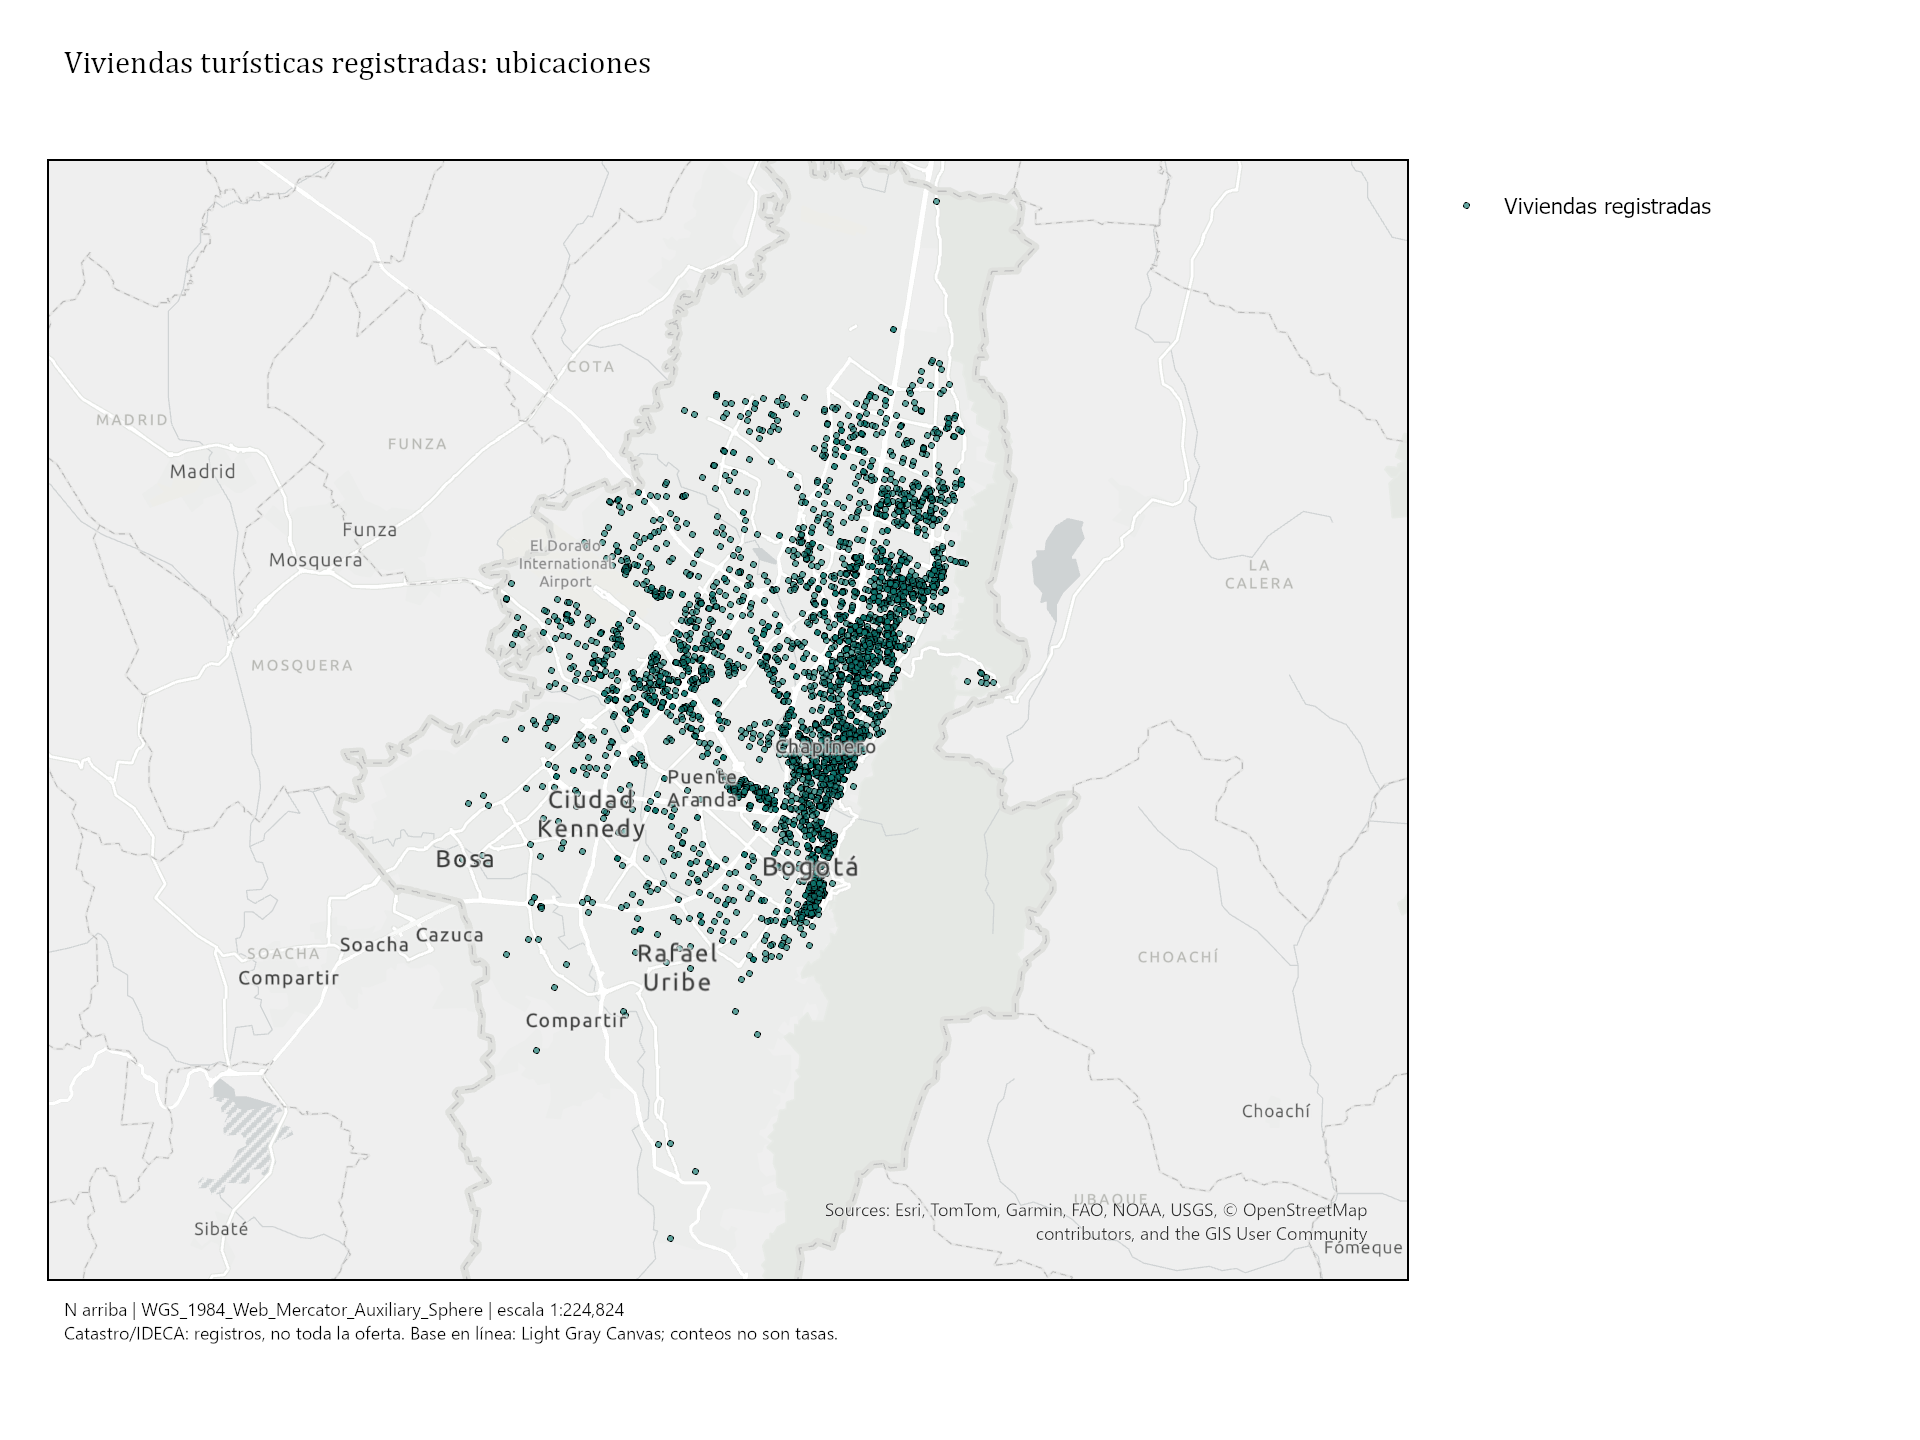

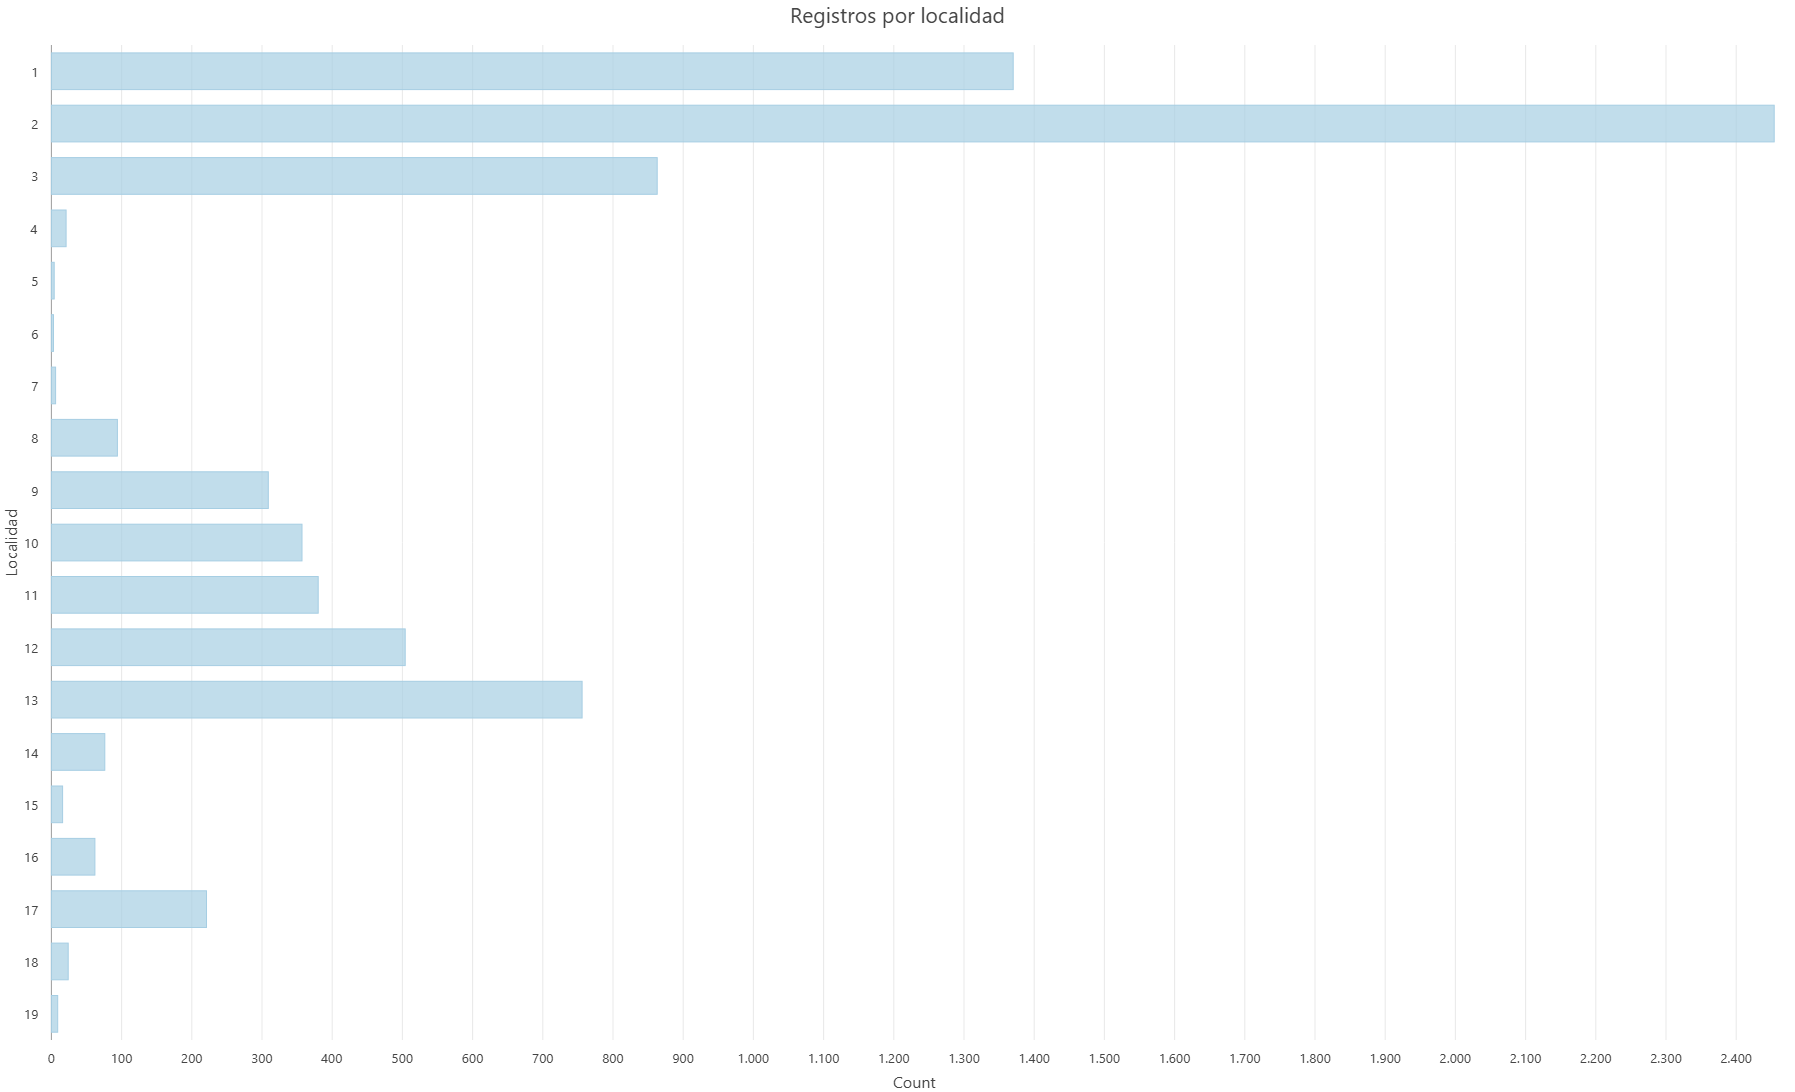

In [21]:
# Representar población actual: color, tamaño y frecuencia tienen denominadores distintos.
map_png(working, 'eda_viviendas')
frequency = Counter(xy_before.values())
csv_path = run / 'multiplicidad_xy.csv'
with csv_path.open('w', newline='', encoding='utf-8') as stream:
    writer = csv.writer(stream); writer.writerow(['Registros_por_XY', 'Sitios'])
    writer.writerows(sorted(frequency.items()))

chart_png(arcpy.charts.Bar(x='LOCALIDAD',aggregation='COUNT',dataSource=working,title='Registros por localidad',rotated=True),'eda_localidad')
# La distribución legible se muestra después de CollectEvents.


Con el norte arriba, los puntos se ven más juntos hacia el lado oriental (derecho) del área representada. Esto describe las ubicaciones del registro, no todavía los conteos por sitio ni una agrupación estadísticamente significativa. La superposición puede ocultar registros; un hueco no demuestra ausencia de turismo ni cobertura completa. Las categorías de las barras son etiquetas, no valores continuos.

### Collect Events y conservación

Coincidencia XY exacta, sin Integrate. Analogía: contar tarjetas en la misma casilla sin moverlas. Igualdad de conteos por coordenada y suma total son obligatorias.

**Precisión de almacenamiento:** la entrada conserva resolución ≈6.71×10⁻⁹ m y Collect Events crea salida con resolución 0.0001 m. La primera ejecución preservada falló por igualdad binaria de flotantes, aun conservando todos los sitios/conteos. Se comprueba correspondencia uno a uno sin colisiones y diferencia ≤10⁻⁷ m; esto no mueve coordenadas ni introduce radio de agrupación. Un cambio mayor detiene el análisis.

In [22]:
# Pasar de registros a sitios conservando suma y posición; no deduplicar.
# Cambiar soporte sin desplazar geometrías: de registros a sitios ocupados.
weighted = str(Path(gdb) / 'Viviendas_ICOUNT')
result = gp_child('CollectEvents', working, weighted)
print(result['messages'])
with arcpy.da.SearchCursor(weighted, ['SHAPE@XY', 'ICOUNT']) as cursor:
    xy_after = {xy: count for xy, count in cursor}
# La GDB de salida cambia resolución; comparar almacenamiento sin modificar geometrías.
# 1e-7 m es límite de comprobación numérica, NO tolerancia de agrupación de eventos.
def numeric_key(xy): return tuple(round(v,7) for v in xy)
before_keys={numeric_key(xy):(xy,count) for xy,count in xy_before.items()}
after_keys={numeric_key(xy):(xy,count) for xy,count in xy_after.items()}
if len(before_keys)!=len(xy_before) or len(after_keys)!=len(xy_after):
    raise ValueError('Colisión en comprobación numérica: no fusionar ni aceptar ambigüedad.')
if set(before_keys)!=set(after_keys) or sum(xy_after.values())!=n:
    raise ValueError('No se conservan sitios y suma total; detener sin ajuste.')
max_storage_delta=0.0
for key,(xy,count) in before_keys.items():
    target,after_count=after_keys[key]
    delta=math.dist(xy,target);max_storage_delta=max(max_storage_delta,delta)
    if count!=after_count or delta>1e-7: raise ValueError('Cambió conteo o posición más allá del límite numérico.')
print('Correspondencia uno a uno; diferencia máxima de almacenamiento (m):',max_storage_delta)
print('Resolución XY entrada/salida (m):',sr.XYResolution,arcpy.Describe(weighted).spatialReference.XYResolution)
print('Registros:', n, 'sitios:', len(xy_after), 'rango ICOUNT:', min(xy_after.values()), max(xy_after.values()))


Hijo CollectEvents PID 76132 | diario: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\CollectEvents_2c65178679c6\process.json


Cierre natural del hijo: 0 | logs: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\CollectEvents_2c65178679c6


Start Time: martes, 22 de septiembre de 2026 2:38:56 p. m.
Succeeded at martes, 22 de septiembre de 2026 2:39:00 p. m. (Elapsed Time: 4.11 seconds)
Correspondencia uno a uno; diferencia máxima de almacenamiento (m): 1.1780402288468106e-08
Resolución XY entrada/salida (m): 6.714873101998366e-09 0.0001
Registros: 7529 sitios: 2919 rango ICOUNT: 1 186


## Describir ICOUNT antes de inferir asociación
Cada fila representa ahora un **sitio ocupado**, con ICOUNT registros. COUNT=N cuenta sitios; SUM=Σxᵢ debe recuperar los registros originales; media=SUM/N. Los lugares sin registros no están en esta tabla.

¿Predominan sitios con pocos registros o con muchos? Compare mediana (valor central), moda (más frecuente), MIN/MAX y media. Q1/Q3 delimitan el 50 % central e IQR=Q3−Q1 mide su amplitud. La desviación estándar mide dispersión en registros/sitio: sumamos las diferencias al cuadrado respecto a la media, dividimos por N−1 (muestral) o por N (poblacional) y tomamos la raíz cuadrada del resultado. Contrastar ambas evita confundir convenciones de cálculo con errores en los datos.

Exportamos estadísticas **solo de ICOUNT**, no de identificadores. `statistics` comprueba media, desviación y totales; los cuartiles se leen de ArcGIS porque su interpolación puede diferir.

**Fuentes, consulta 2026-09-16:** Esri Pro 3.6, [Field Statistics To Table](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/data-management/field-statistics-to-table.htm), Parameters/Python; [Interact with statistics](https://pro.arcgis.com/en/pro-app/3.6/help/analysis/geoprocessing/data-engineering/view-statistics.htm), Select fields/Calculate/Types of statistics. La UI documenta N−1; no demuestra la convención del exportador: se contrasta abajo.

In [23]:
# Exportar únicamente el atributo que responde a la pregunta, con nombres explícitos.
stat_mapping = [
    ['FIELDNAME', 'Campo'], ['COUNT', 'Cantidad'], ['NULLS', 'Nulos'],
    ['SUM', 'Suma'], ['MINIMUM', 'Minimo'], ['MAXIMUM', 'Maximo'],
    ['MEAN', 'Media'], ['MEDIAN', 'Mediana'], ['MODE', 'Moda'],
    ['STANDARDDEVIATION', 'Desv'], ['FIRSTQUARTILE', 'Q1'],
    ['THIRDQUARTILE', 'Q3'], ['INTERQUARTILERANGE', 'InterquartileRange'],
]
statistics_result = gp_child('FieldStatisticsToTable', 
    weighted, ['ICOUNT'], gdb, [['NUMERIC', 'Descriptivos_ICOUNT']],
    out_statistics=stat_mapping,
)
print(statistics_result['messages'])
stats_table = str(Path(gdb) / 'Descriptivos_ICOUNT')
stat_fields = [pair[1] for pair in stat_mapping]
actual_fields = {field.name for field in arcpy.ListFields(stats_table)}
if not set(stat_fields).issubset(actual_fields):
    raise ValueError('La tabla no contiene los nombres solicitados; revisar esquema.')
with arcpy.da.SearchCursor(stats_table, stat_fields) as cursor:
    statistic_rows = list(cursor)
if len(statistic_rows) != 1:
    raise ValueError('Se esperaba una fila estadística para ICOUNT.')
stats = dict(zip(stat_fields, statistic_rows[0]))
# Pro 3.6.2 conserva este nombre físico para IQR; se declara la equivalencia lógica.
stats['IQR'] = stats['InterquartileRange']
print('Tabla ArcGIS, sin selección ni agrupación:', stats)


Hijo FieldStatisticsToTable PID 6688 | diario: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\FieldStatisticsToTable_01d952ef1265\process.json


Cierre natural del hijo: 0 | logs: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\FieldStatisticsToTable_01d952ef1265


Start Time: martes, 22 de septiembre de 2026 2:39:15 p. m.
Succeeded at martes, 22 de septiembre de 2026 2:39:20 p. m. (Elapsed Time: 5.46 seconds)


Tabla ArcGIS, sin selección ni agrupación:

 {'Campo': 'ICOUNT', 'Cantidad': 2919, 'Nulos': 0, 'Suma': 7529.0, 'Minimo': 1.0, 'Maximo': 186.0, 'Media': 2.57930798218568, 'Mediana': 1.0, 'Moda': 1.0, 'Desv': 8.2462401385683, 'Q1': 1.0, 'Q3': 1.0, 'InterquartileRange': 0.0, 'IQR': 0.0}


una fila resume ICOUNT, no un sitio. Cantidad cuenta valores no nulos; Suma conserva registros. La siguiente celda verifica estas identidades y distingue N de N−1 antes de interpretar dispersión.

**Esquema observado Pro 3.6.2:** el campo de rango intercuartílico se conserva como `InterquartileRange`; `IQR` es solo su nombre lógico en el diccionario Python. No se asume que el exportador siempre acepte abreviaturas.

In [24]:
# Contrastar fórmulas sin modificar registros; statistics es biblioteca estándar, no un SIG alternativo.
import statistics
with arcpy.da.SearchCursor(weighted, ['ICOUNT']) as cursor:
    icount = [row[0] for row in cursor]
if any(value is None or value < 1 or int(value) != value for value in icount):
    raise ValueError('ICOUNT requiere conteos enteros positivos en sitios ocupados.')
frequency_icount = Counter(icount)
n_sites, n_records = len(icount), sum(icount)
sample_sd = statistics.stdev(icount)
population_sd = statistics.pstdev(icount)
mean_icount = statistics.mean(icount)
checks = {'Cantidad': n_sites, 'Nulos': 0, 'Suma': n_records,
          'Minimo': min(icount), 'Maximo': max(icount),
          'Media': mean_icount, 'Mediana': statistics.median(icount)}
for field, expected in checks.items():
    if not math.isclose(float(stats[field]), expected, rel_tol=1e-10, abs_tol=1e-10):
        raise ValueError(f'Descriptivo no conciliado: {field}.')
match_sample = math.isclose(stats['Desv'], sample_sd, rel_tol=1e-10, abs_tol=1e-12)
match_population = math.isclose(stats['Desv'], population_sd, rel_tol=1e-10, abs_tol=1e-12)
if not (match_sample or match_population):
    raise ValueError('Desviación exportada no coincide con N ni N−1; investigar.')
sd_convention = ('indistinguible entre N y N−1' if match_sample and match_population
                 else 'N−1 (muestral)' if match_sample else 'N (poblacional)')
if not math.isclose(stats['IQR'], stats['Q3'] - stats['Q1'], abs_tol=1e-10):
    raise ValueError('IQR no coincide con Q3−Q1.')
print('Frecuencia exacta ICOUNT → sitios:', dict(sorted(frequency_icount.items())))
print(f'Desviación exportada={stats["Desv"]:.12f}; stdev={sample_sd:.12f}; pstdev={population_sd:.12f}')
print('Convención OBSERVADA de la tabla:', sd_convention)
print('UI documenta N−1: comparar población/selección antes de equiparar resultados.')
print('Moda(s) por frecuencia:', statistics.multimode(icount), '| Moda exportada:', stats['Moda'])


Frecuencia exacta ICOUNT → sitios: {1: 2295, 2: 259, 3: 103, 4: 48, 5: 33, 6: 28, 7: 13, 8: 12, 9: 17, 10: 14, 11: 8, 12: 6, 13: 5, 14: 6, 15: 3, 16: 3, 17: 3, 19: 5, 20: 3, 21: 3, 22: 1, 23: 2, 25: 1, 26: 1, 27: 1, 28: 3, 29: 1, 30: 2, 31: 2, 32: 2, 33: 1, 34: 2, 36: 1, 37: 1, 39: 1, 40: 1, 41: 2, 42: 1, 43: 1, 44: 1, 46: 1, 47: 1, 48: 1, 52: 1, 53: 2, 54: 2, 59: 2, 61: 1, 63: 1, 65: 1, 68: 1, 71: 2, 73: 1, 80: 1, 89: 1, 97: 1, 105: 1, 115: 1, 153: 1, 186: 1}
Desviación exportada=8.246240138568; stdev=8.246240138568; pstdev=8.244827506414
Convención OBSERVADA de la tabla: N−1 (muestral)
UI documenta N−1: comparar población/selección antes de equiparar resultados.
Moda(s) por frecuencia: [1] | Moda exportada: 1.0


La comparación anterior permite reconocer qué desviación calcula el exportador; no certifica la calidad del registro turístico.

### ¿Cuántos sitios tienen un solo registro?
Calculamos la proporción con ICOUNT=1 y examinamos los valores altos. Las cercas Q1−1.5·IQR y Q3+1.5·IQR señalan extremos descriptivos: si IQR=0, pueden marcar todos los conteos >1. No son una razón para eliminarlos.

La asimetría es el promedio de desviaciones al cubo dividido por la desviación poblacional al cubo. Un valor positivo indica una cola hacia conteos altos; interprételo junto con mediana, cuartiles y máximo, no como prueba de error o normalidad.

In [25]:
# Interpretar sitios y cola sin convertir multiplicidad en riesgo ni borrar extremos.
singletons = frequency_icount[1]
lower_fence = stats['Q1'] - 1.5 * stats['IQR']
upper_fence = stats['Q3'] + 1.5 * stats['IQR']
flagged = sum(value < lower_fence or value > upper_fence for value in icount)
# Tercer momento estandarizado descriptivo; no es prueba de normalidad.
skew_moment = (sum((value - mean_icount) ** 3 for value in icount) / n_sites
               / population_sd ** 3) if population_sd else None
print(f'{n_records:,} registros en {n_sites:,} sitios; media={mean_icount:.6f} registros/sitio ocupado.')
print(f'Mediana={stats["Mediana"]}; moda={stats["Moda"]}; mínimo={stats["Minimo"]}; máximo={stats["Maximo"]}.')
print(f'Sitios con un solo registro: {singletons:,}/{n_sites:,} = {singletons/n_sites:.2%}.')
print(f'Q1={stats["Q1"]}; Q3={stats["Q3"]}; IQR={stats["IQR"]}; cercas=[{lower_fence}, {upper_fence}].')
print(f'Fuera de cercas: {flagged:,} sitios ({flagged/n_sites:.2%}); no se borra ninguno.')
if stats['IQR'] == 0:
    print('IQR degenerado: el 50 % central coincide. Marcar otros valores no demuestra errores.')
print(f'Máximo: {max(icount)} registros/sitio en {frequency_icount[max(icount)]} sitios.')
print('Asimetría de momento:', skew_moment, '| cola de multiplicidad, no evidencia de normalidad.')
print('La media no es riesgo/tasa: faltan exposición, sitios con cero y denominador poblacional.')
print('El histograma pierde posición; el mapa muestra dónde están los conteos, no sus causas.')


7,529 registros en 2,919 sitios; media=2.579308 registros/sitio ocupado.
Mediana=1.0; moda=1.0; mínimo=1.0; máximo=186.0.
Sitios con un solo registro: 2,295/2,919 = 78.62%.
Q1=1.0; Q3=1.0; IQR=0.0; cercas=[1.0, 1.0].
Fuera de cercas: 624 sitios (21.38%); no se borra ninguno.
IQR degenerado: el 50 % central coincide. Marcar otros valores no demuestra errores.
Máximo: 186 registros/sitio en 1 sitios.
Asimetría de momento: 11.114977348510617 | cola de multiplicidad, no evidencia de normalidad.
La media no es riesgo/tasa: faltan exposición, sitios con cero y denominador poblacional.
El histograma pierde posición; el mapa muestra dónde están los conteos, no sus causas.


La mediana y la moda son 1, pero la media es 2.579308; 78.62 % de los sitios tienen un registro. IQR=0 concentra el centro, no todos los datos. La cola eleva la media; las cercas no justifican limpieza.

### Distribución discreta: tabla completa, barras, caja y mapa
Las barras muestran cuántos sitios tienen cada conteo. El panel completo incluye todos; el segundo oculta ICOUNT=1 para ver mejor los menos frecuentes, sin eliminarlos. La caja resume mediana, cuartiles y cercas 1.5×IQR: con IQR=0 queda colapsada en 1. Los valores fuera de las cercas se conservan.

El mapa separa 1 y 2 y agrupa la cola; verde claro/oscuro significa menos/más registros, no frío/calor inferencial. Fuente: elaboración docente con datos ejecutados; Esri Pro 3.6 [Bar](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/bar.htm) y [Box](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/box.htm), Syntax/Parameters/Methods, consulta 2026-09-16.


En las barras, 01 a 10 son conteos exactos; los prefijos 11., 12., 13. y 14. ordenan intervalos de la cola, no son valores adicionales. Los puntos del eje vertical son separadores de miles cuando así los presenta ArcGIS; lea la tabla exacta para evitar ambigüedad.
La etiqueta 101+ agrupa desde 101 hasta el máximo observado (186 en P03), no una categoría abierta con datos desconocidos.

Campo,Tipo,Rol,Unidad,Ejemplo,Nulos / cero
ICOUNT,Integer,Registros originales con XY idéntica,registros por sitio,1,No hay nulos ni ceros: sitios sin registros no se incorporan


ICOUNT exacto,Sitios,Porcentaje de sitios
1,2295,78.623
2,259,8.873
3,103,3.529
4,48,1.644
5,33,1.131
6,28,0.959
7,13,0.445
8,12,0.411
9,17,0.582
10,14,0.48


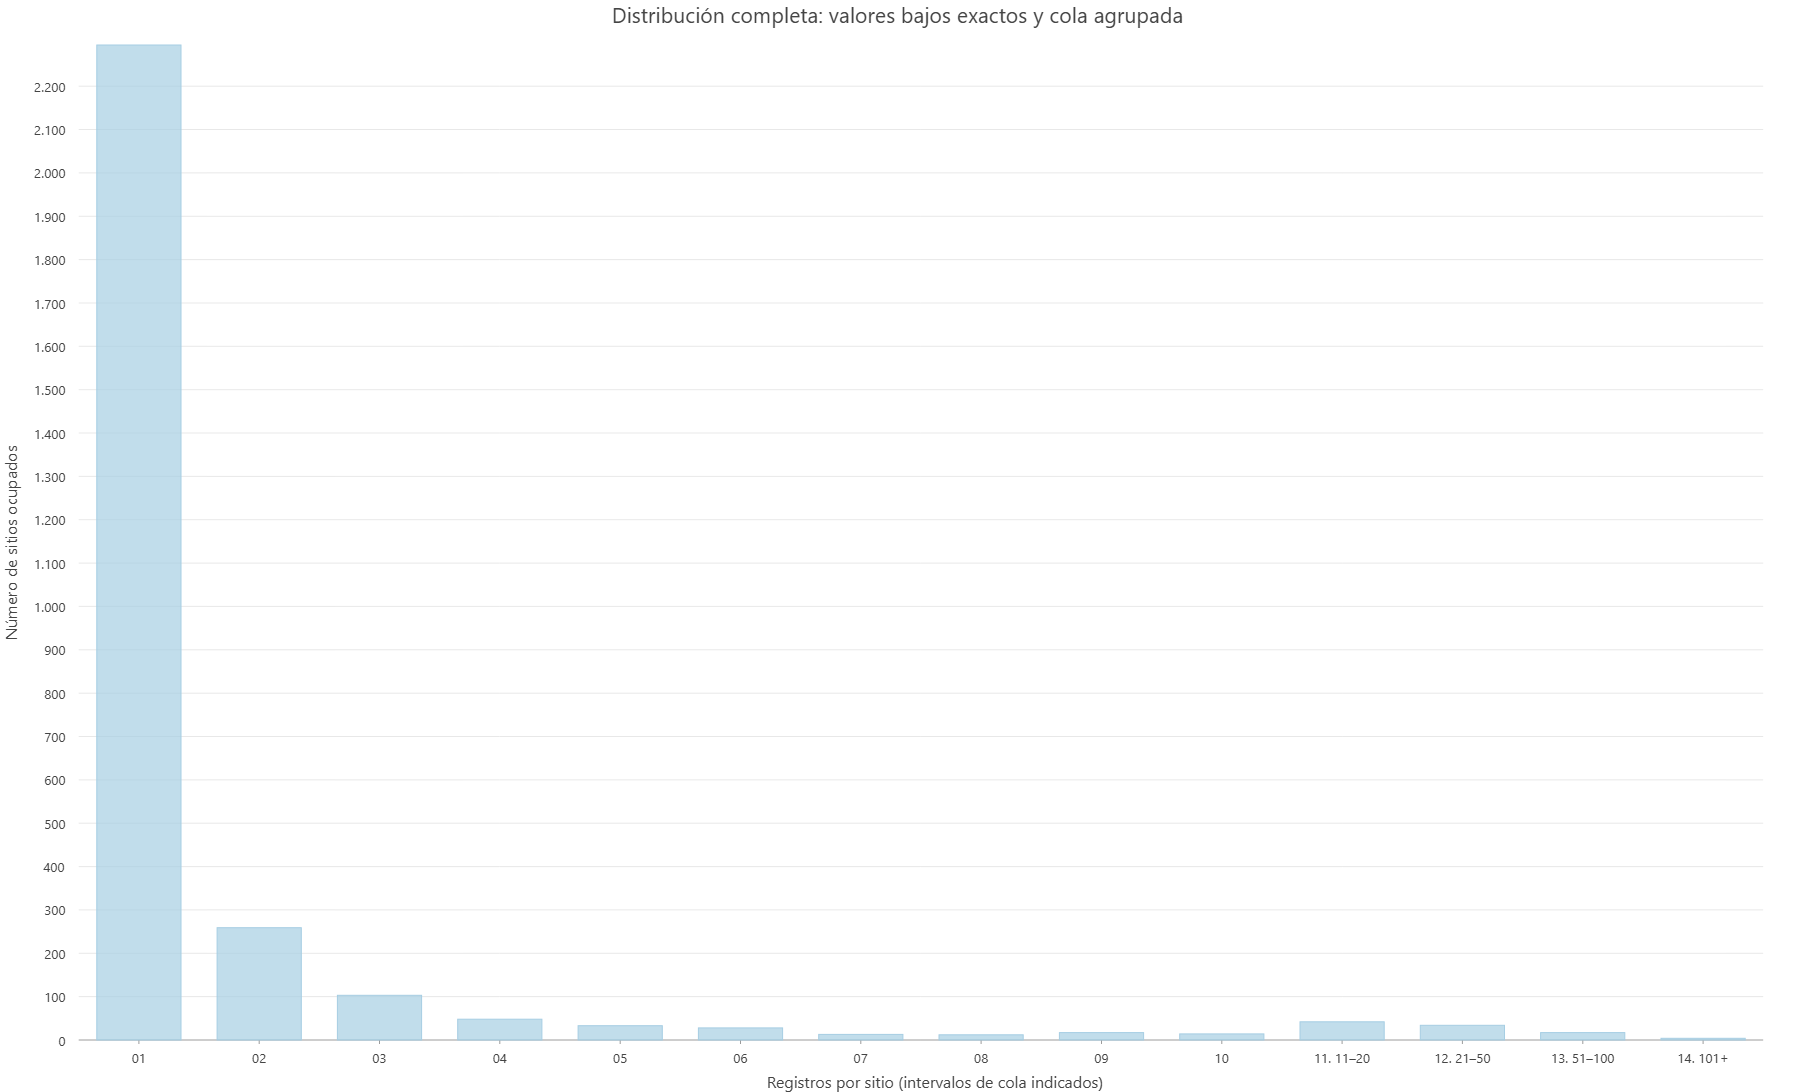

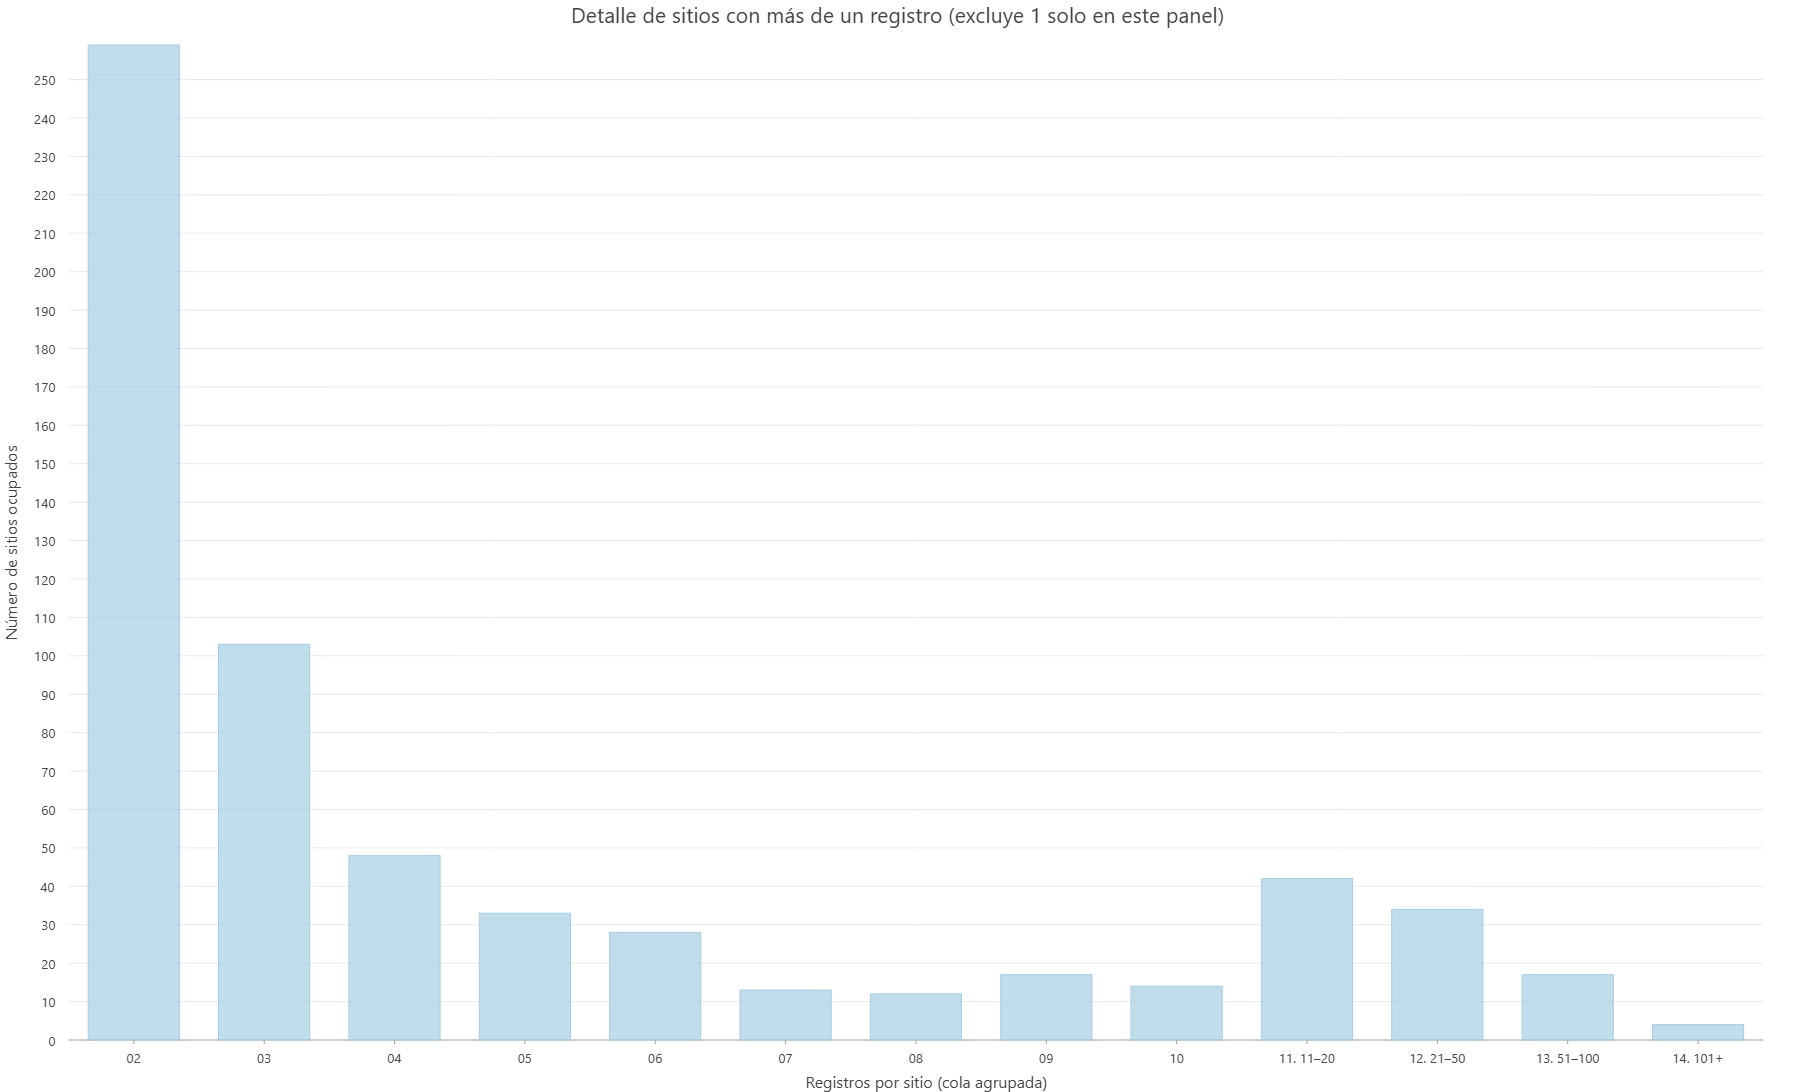

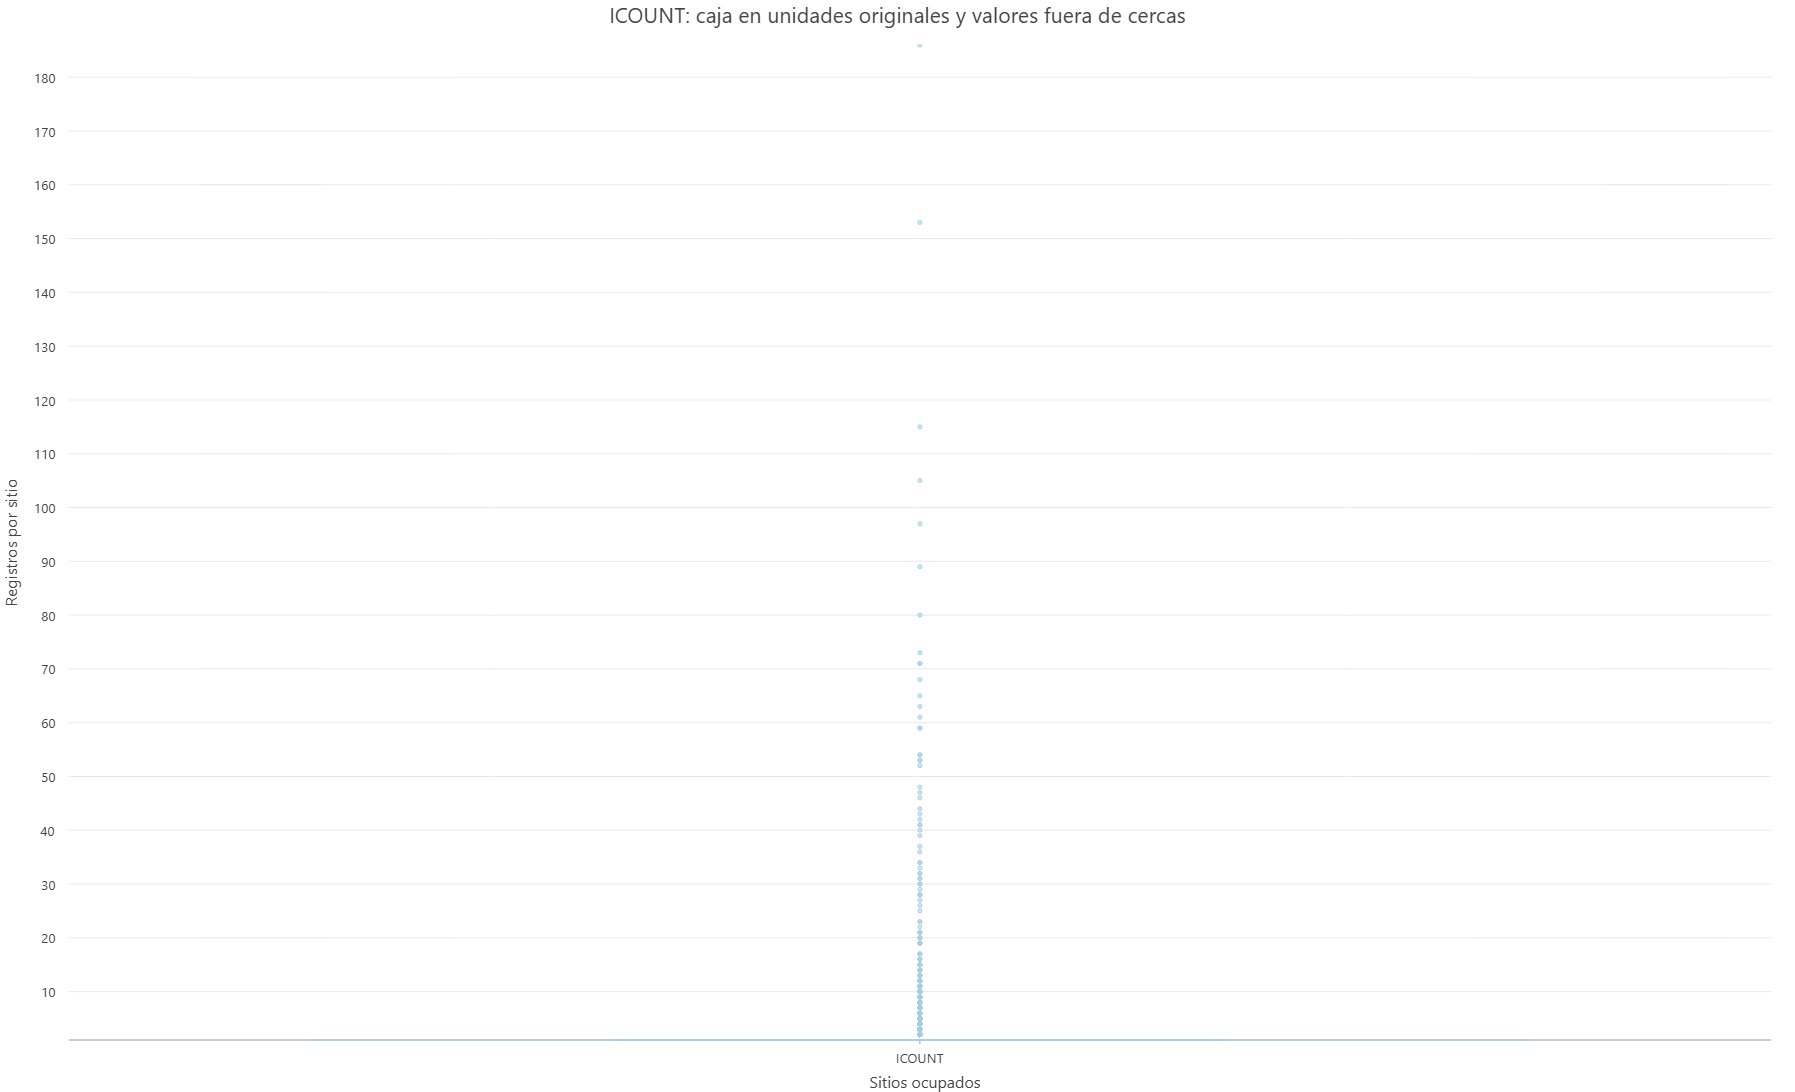

Lectura: 2,295 sitios tienen un registro; 624 tienen más de uno; máximo=186.
Q1=1.0; Q3=1.0; IQR=0.0. Caja colapsada en 1: valores mayores no son errores a eliminar.


Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


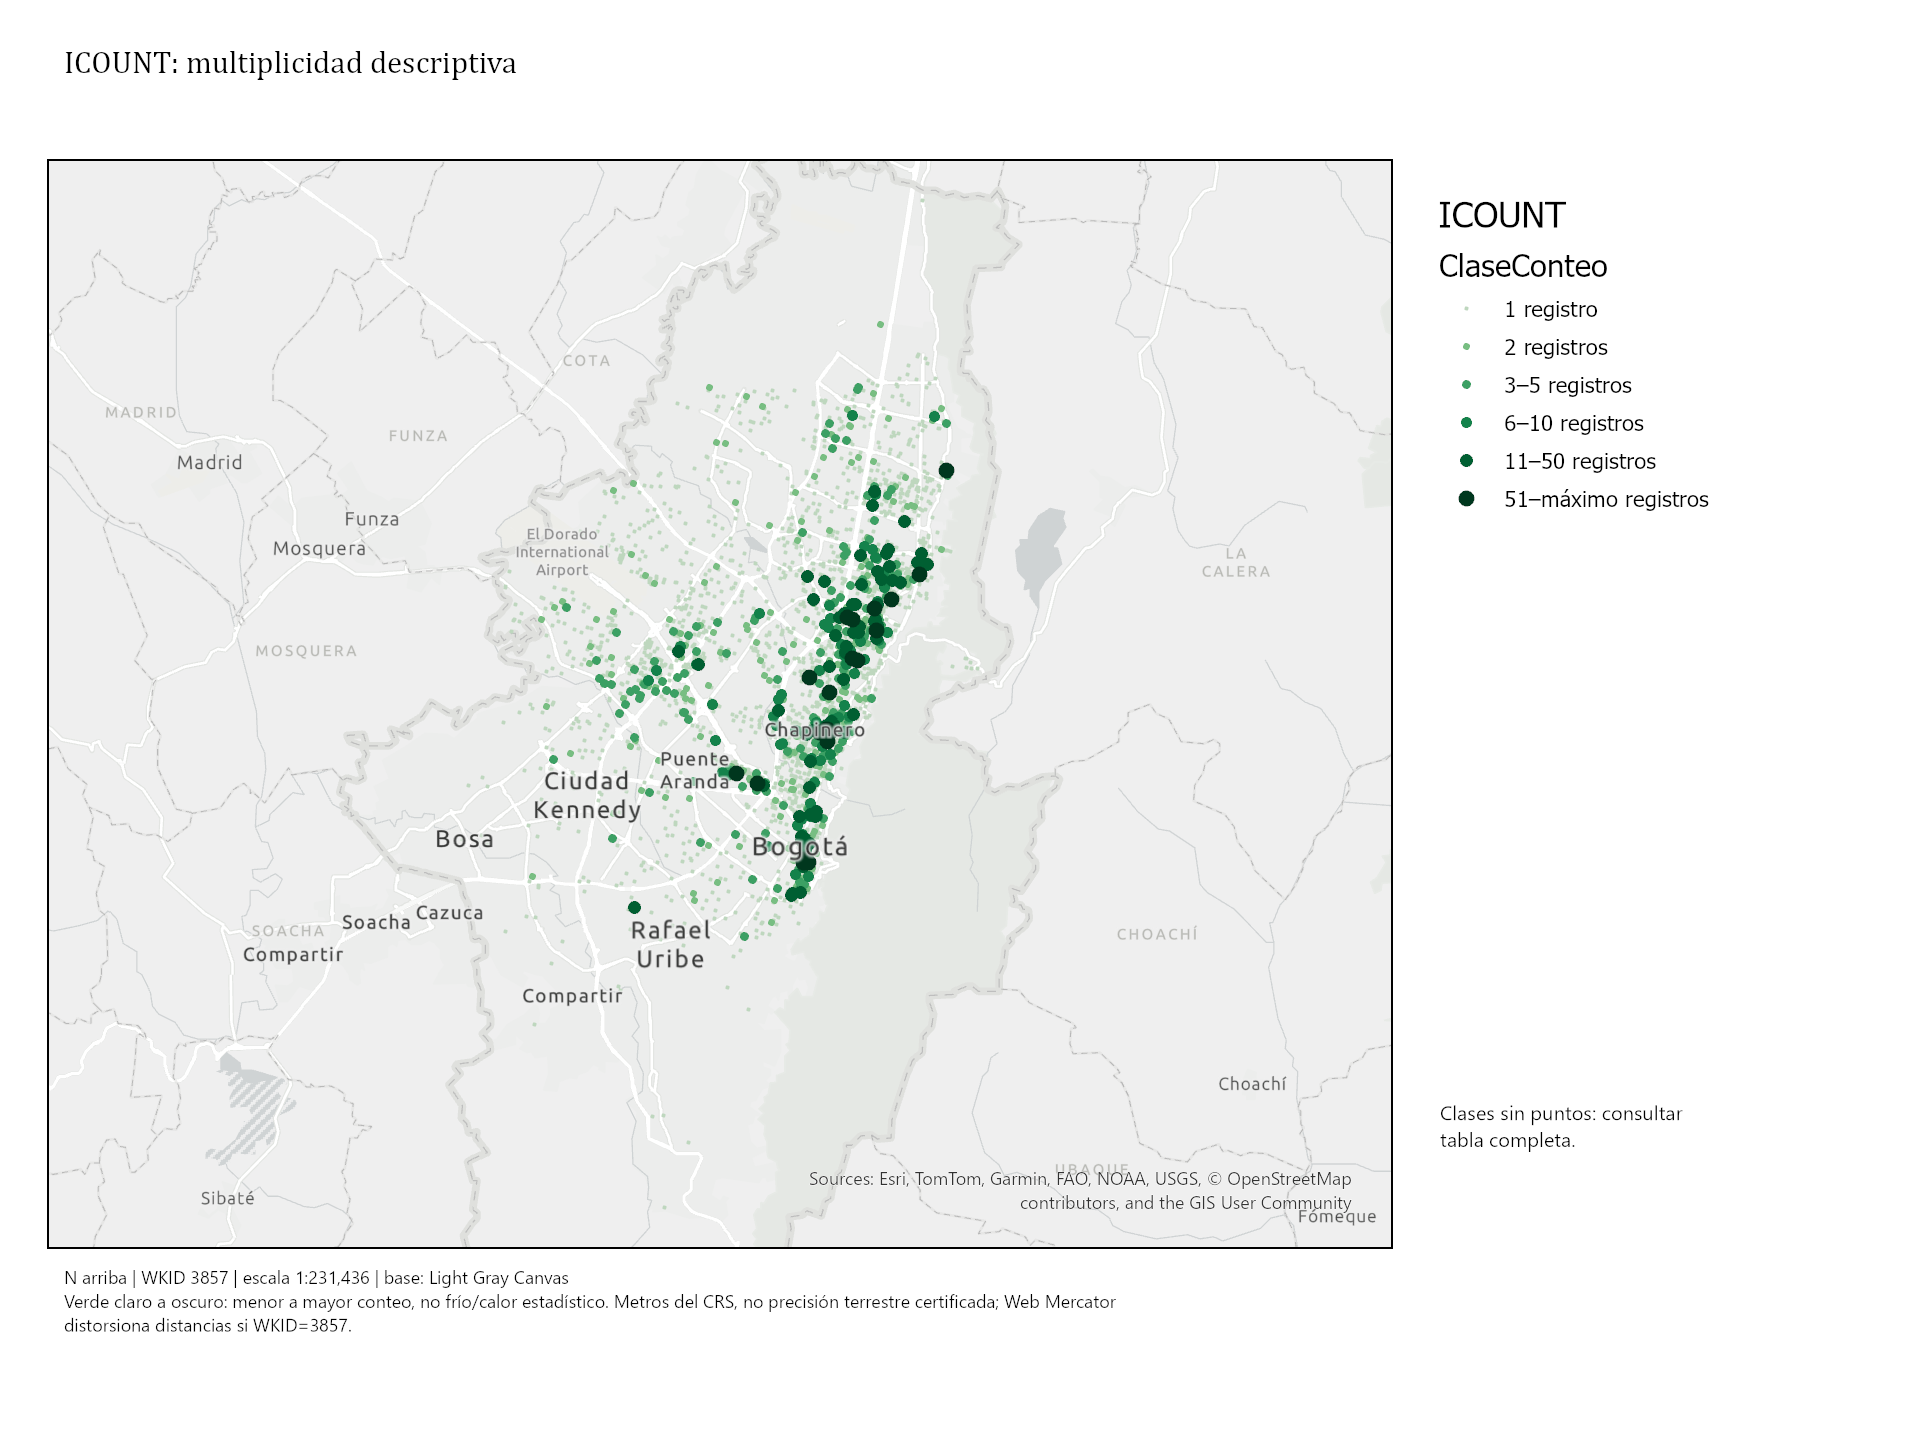

In [26]:
# Frecuencia exacta: denominador = sitios ocupados, no todo el territorio.
tabla_visible(['Campo', 'Tipo', 'Rol', 'Unidad', 'Ejemplo', 'Nulos / cero'], [
    ['ICOUNT', next(f.type for f in arcpy.ListFields(weighted) if f.name == 'ICOUNT'),
     'Registros originales con XY idéntica', 'registros por sitio', min(icount),
     'No hay nulos ni ceros: sitios sin registros no se incorporan'],
])
tabla_visible(['ICOUNT exacto', 'Sitios', 'Porcentaje de sitios'],
              [[value, count, round(100*count/n_sites, 3)] for value,count in sorted(frequency_icount.items())])
# Valores 1 a 10 exactos; cola agrupada explícitamente, sin truncar el total.
frequency_rows = [(f'{v:02d}', frequency_icount[v]) for v in range(1, min(10, int(max(icount)))+1)]
for lower, upper, label in [(11,20,'11. 11–20'), (21,50,'12. 21–50'), (51,100,'13. 51–100'), (101,int(max(icount)),'14. 101+')]:
    if max(icount) >= lower:
        frequency_rows.append((label, sum(count for value,count in frequency_icount.items() if lower <= value <= upper)))
assert sum(count for _,count in frequency_rows) == n_sites
frequency_table = tabla_frecuencia('Frecuencia_legible', frequency_rows)
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=frequency_table,
    title='Distribución completa: valores bajos exactos y cola agrupada',
    xTitle='Registros por sitio (intervalos de cola indicados)', yTitle='Número de sitios ocupados'), 'frecuencia_completa')
# Panel sin 1: no altera el universo, permite leer la cola minoritaria.
tail_table = tabla_frecuencia('Frecuencia_cola', frequency_rows[1:])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=tail_table,
    title='Detalle de sitios con más de un registro (excluye 1 solo en este panel)',
    xTitle='Registros por sitio (cola agrupada)', yTitle='Número de sitios ocupados'), 'frecuencia_cola')
chart_png(arcpy.charts.Box(y='ICOUNT', standardizeValues=False, showOutliers=True,
    dataSource=weighted, title='ICOUNT: caja en unidades originales y valores fuera de cercas',
    xTitle='Sitios ocupados', yTitle='Registros por sitio'), 'caja_icount')
print(f'Lectura: {frequency_icount[1]:,} sitios tienen un registro; {n_sites-frequency_icount[1]:,} tienen más de uno; máximo={max(icount)}.')
print(f'Q1={stats["Q1"]}; Q3={stats["Q3"]}; IQR={stats["IQR"]}. Caja colapsada en 1: valores mayores no son errores a eliminar.')
# Clasificar únicamente la salida nueva; las clases descriptivas no son significancia.
arcpy.management.AddField(weighted, 'ClaseConteo', 'TEXT', field_length=30)
with arcpy.da.UpdateCursor(weighted, ['ICOUNT','ClaseConteo']) as cursor:
    for row in cursor:
        value = row[0]
        row[1] = '01' if value == 1 else '02' if value == 2 else '03' if value <= 5 else '04' if value <= 10 else '05' if value <= 50 else '06'
        cursor.updateRow(row)
count_styles = {
    '01': ('1 registro', [190,215,190,100], 2),
    '02': ('2 registros', [120,190,130,100], 3),
    '03': ('3–5 registros', [60,160,100,100], 4),
    '04': ('6–10 registros', [20,130,75,100], 5),
    '05': ('11–50 registros', [0,95,50,100], 6),
    '06': ('51–máximo registros', [0,55,30,100], 7),
}
mapa_categorias(weighted, 'ClaseConteo', 'mapa_icount_legible', 'ICOUNT: multiplicidad descriptiva', count_styles,
    'Verde claro a oscuro: menor a mayor conteo, no frío/calor estadístico. Metros del CRS, no precisión terrestre certificada; Web Mercator distorsiona distancias si WKID=3857.')


En el mapa, muchos símbolos grandes y oscuros aparecen hacia el lado oriental (derecho): allí se observan varios sitios con conteos altos. También hay sitios con varios registros en otras partes del encuadre. Es una descripción visual, no una delimitación administrativa ni una explicación de sus causas. Moran permitirá examinar la semejanza entre vecinos.

Lea las cifras bajo los gráficos. Un intervalo con frecuencia cero significa que ningún sitio tiene esos conteos, no que haya territorios sin turismo.

### Data Engineering: ejercicio manual opcional sobre la copia
**Pasos documentados, no ejecutados ni verificados en la interfaz de Pro en esta corrida.** No se inventa `arcpy.DataEngineering`.
1. Abra el APRX de sitios de esta ejecución: apunta a `trabajo.gdb`, no al original. Añada desde esa misma GDB la copia previa a Collect Events, para distinguir registros de sitios.
2. En esa copia abra Data Engineering; añada **LOCALIDAD y SUBCATRNT** con **Add To Statistics** o arrastrándolos; pulse **Calculate**. No agregue IDs/códigos para obtener medias. No active limpieza.
3. Examine frecuencias y previsualización de barras para categorías; contraste cobertura con mapa. Inspeccione Nulls y seleccione los nulos desde su estadística cuando existan. Un cero no es un nulo; no reemplace ni elimine. Anote número seleccionado y total.
4. Quite la selección. En la capa de sitios añada **ICOUNT** y calcule: COUNT=sitios, SUM=registros; centro/dispersión describen multiplicidad. Abra el histograma numérico y relaciónelo con el mapa graduado.
5. Seleccione temporalmente ICOUNT > 1 y recalcule: cambia el denominador. Esas estadísticas no deben coincidir con toda la capa. Quite la selección y calcule otra vez.
6. Abra `Descriptivos_ICOUNT` y compare campo, población, nulos, COUNT, SUM, media y cuartiles. La UI documenta desviación N−1: consulte la convención **observada** del exportador (puede ser N) antes de atribuir diferencias a datos sucios.
7. Documente su observación manual aparte; no guarde cambios sobre originales, no repare, deduplique ni impute. Este itinerario no equivale a interacción ejecutada.

Fuente: Esri, Pro 3.6, [Interact with statistics](https://pro.arcgis.com/en/pro-app/3.6/help/analysis/geoprocessing/data-engineering/view-statistics.htm), selección/cálculo/tipos; consulta del 2026-09-16.

### Histograma del soporte ocupado
El histograma agrupa ICOUNT en hasta 20 intervalos (4/10 para rangos pequeños): eje x = registros por sitio; eje y = cantidad de sitios. Los límites decimales separan intervalos, no son conteos posibles. Para conocer frecuencias exactas, vuelva a las barras y la tabla.

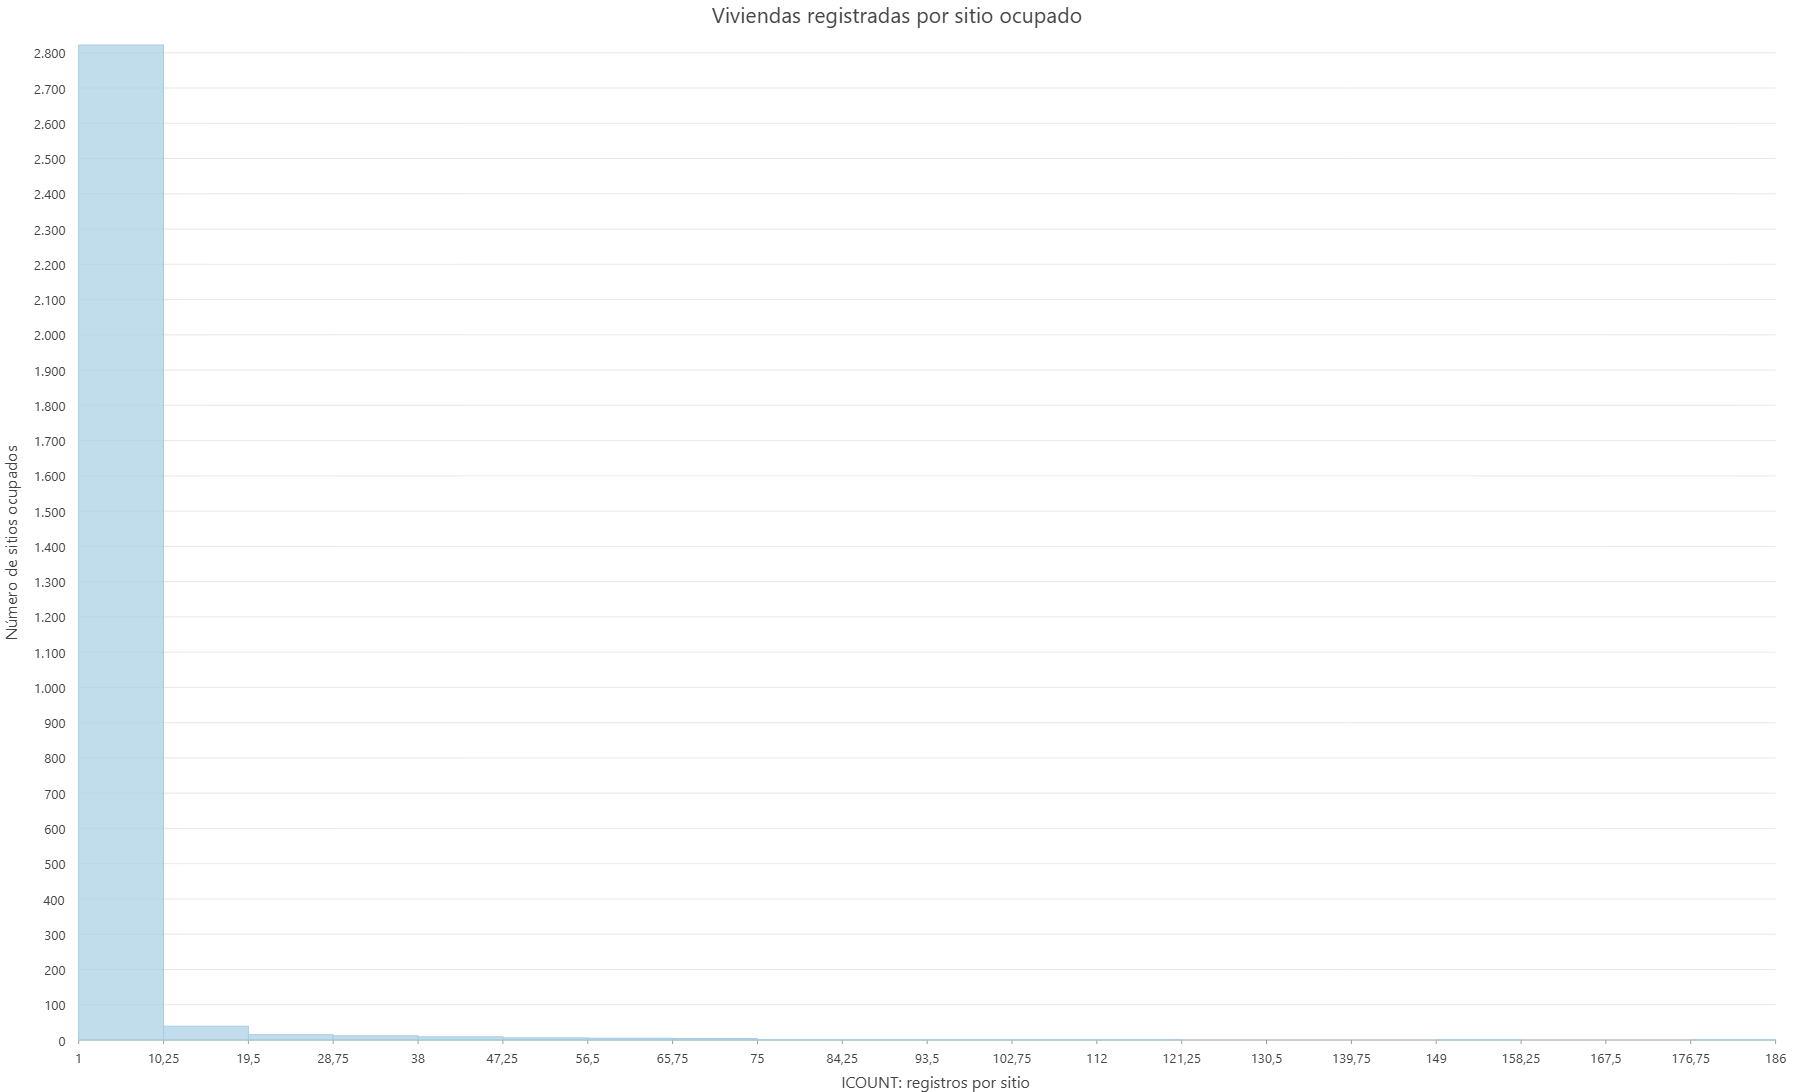

In [27]:
# Relacionar distribución de multiplicidad con ubicación, sin inferir riesgo.
chart_png(arcpy.charts.Histogram(x='ICOUNT', dataSource=weighted, binCount=min(20, int(max(icount))), xTitle='ICOUNT: registros por sitio', yTitle='Número de sitios ocupados', title='Viviendas registradas por sitio ocupado'), 'histograma_icount')
if len(set(xy_after.values())) < 2:
    raise ValueError('ICOUNT constante: este Moran no está definido, aunque la nube parezca agrupada.')

## ¿Se parecen los conteos de sitios vecinos?
Moran global responde esta pregunta para ICOUNT en los sitios ocupados. No mide densidad de turistas ni localiza por sí solo puntos calientes; tampoco evalúa los lugares sin registros.
INVERSE_DISTANCE da mayor influencia a vecinos cercanos; EUCLIDEAN_DISTANCE usa distancia recta y ROW estandariza por filas. **Umbral vacío** calcula un límite que asegura al menos un vecino para cada entidad; **cero** significa sin umbral. No se selecciona por optimizar p ni se fija una distancia histórica como si fuera parámetro nuevo.

La celda devuelve estadísticas y un informe HTML dentro de la carpeta de ejecución; si queda fuera, se detiene.

Comparamos el resultado con H₀: valores distribuidos aleatoriamente entre los sitios analizados, manteniendo fija la vecindad. ROW hace que los pesos de cada sitio sumen uno donde hay vecinos.

| Columna | Lectura sencilla |
|---|---|
| Distance | Distancia efectiva en metros del CRS; modifica vecinos. En incremental son radios acumulados, no anillos. |
| MoransI / I | Asociación adimensional entre desviaciones de ICOUNT de vecinos. Comparar con esperado y pesos: no tiene límites universales −1/+1 ni expresa porcentaje de riesgo. |
| ExpectedI | Esperado bajo H₀ y el soporte/pesos empleados; leer cada fila, sin imponer el número original de sitios a todas las bandas. |
| Variance | Variabilidad de **I bajo H₀**, no varianza de ICOUNT, coordenadas o distancias. Se usa para estandarizar. |
| z_score / ZScore | (I−ExpectedI)/√Variance: cuántas desviaciones nulas separan observado y esperado. Signo=encima/debajo del esperado, no bueno/malo. |
| p_value / PValue | Compatibilidad de un resultado al menos tan extremo con H₀; no probabilidad de que H₀ sea cierta. 0 mostrado significa por debajo de la precisión de representación/cálculo, no probabilidad matemáticamente nula. |

I por encima del esperado favorece semejanza vecinal; por debajo, contraste, condicionado a pesos y soporte. Un z grande y p pequeño puede acompañar I pequeño: significancia no es magnitud ni causalidad. El 95 % es referencia **nominal de un contraste fijado**, no corrección después de mirar curvas. Primer/máximo pico local de z y máximo numérico no son lo mismo. Conservar todas las bandas; seleccionar pico o segunda exploración con los mismos datos no es validación independiente. Fuente: Esri Pro 3.6, interpretación de Moran e incremental; referencias completas al final.

Hijo SpatialAutocorrelation PID 78348 | diario: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\SpatialAutocorrelation_87580d6ab395\process.json


Cierre natural del hijo: 0 | logs: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\SpatialAutocorrelation_87580d6ab395


Start Time: martes, 22 de septiembre de 2026 2:40:31 p. m.
WARNING 000853: The default neighborhood search threshold was 4822.1390 meters.
WARNING 001420: The number of neighbors for at least one feature exceeds 1000, you may want to change your conceptualization of spatial relationships to avoid the potential of running out of memory.
WARNING 001422: Features with number of neighbors exceeding warning value (only includes first 30): OBJECTID = 588, 609, 611, 619, 620, 621, 622, 626, 629, 631, 638, 641, 644, 647, 657, 658, 659, 661, 663, 664, 666, 667, 671, 674, 675, 676, 678, 679, 680, 684.

 Global Moran's I Summary 
Moran's Index     0.025782 
Expected Index    -0.000343
Variance          0.000006 
z-score           10.661289
p-value           0.000000 
Distance measured in meters

Writing html report....
../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\MoransI_Result_52036_78348_.html
Succeeded at martes, 22 de septiembre de 2026 2:41:

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\IPython\core\display.py:475: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



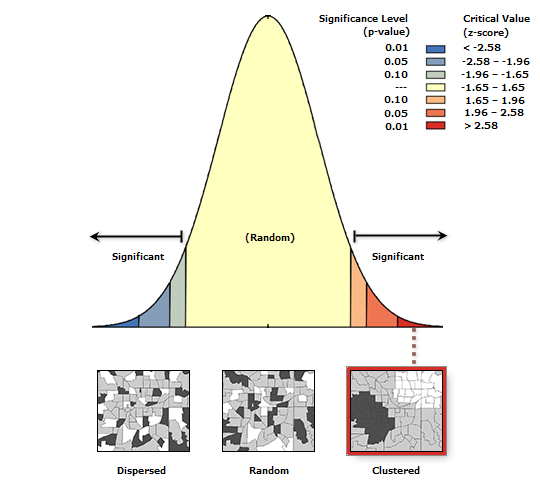

Informe original local: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\MoransI_Result_52036_78348_.html | navegador y descarga no comprobados


In [28]:
# Firma comprobada en ayuda local ArcPy Pro 3.6.2; umbral None conserva cálculo automático.
result = gp_child('SpatialAutocorrelation', weighted, 'ICOUNT', 'GENERATE_REPORT', 'INVERSE_DISTANCE', 'EUCLIDEAN_DISTANCE', 'ROW', None)
print(result['messages'])
# Diccionario explícito devuelto por el hijo, no un ArcPy Result simulado.
outputs = result['outputs']
for name, value in outputs.items():
    print(name, value)
html_paths = [Path(value) for value in outputs.values() if str(value).lower().endswith(('.html', '.htm'))]
if not html_paths:
    raise RuntimeError('No se identificó el informe HTML; inspeccionar salidas reales antes de seguir.')
for report in html_paths:
    if not report.is_file() or not report.resolve().is_relative_to(run.resolve()):
        raise RuntimeError('El informe no está disponible dentro de la ejecución aislada; revisar scratch.')
print('Abrir el HTML local indicado para leer I, esperado, z, p y distancia calculada; no es publicación.')

# Mostrar el informe generado, sin confundirlo con un mapa de hotspots.
import base64, re
for report in html_paths:
    report_html = report.read_text(encoding='utf-8')
    # Solo imágenes del informe oficial instalado, no lecturas arbitrarias.
    images_dir = Path(INFO_PRO['InstallDir'])/'Resources/ArcToolbox/Scripts/Images'
    def embed_report_image(match):
        image_path = Path(match.group(1).removeprefix('file://'))
        if image_path.parent.resolve() != images_dir.resolve():
            raise ValueError('Recurso de informe fuera de Images de ArcGIS Pro.')
        data = base64.b64encode(image_path.read_bytes()).decode('ascii')
        return 'src="data:image/png;base64,' + data + '"'
    report_html = re.sub(r'src="(file://[^"]+)"', embed_report_image, report_html)
    # Aislar estilos del informe para no modificar el resto del notebook.
    display(HTML('<iframe title="Informe Moran global" width="100%" height="1000" srcdoc="'
                 + escape(report_html, quote=True) + '"></iframe>'))
    payload = base64.b64encode(report_html.encode('utf-8')).decode('ascii')
    display(HTML(f'<a download="Moran_global.html" href="data:text/html;base64,{payload}">Descargar informe autocontenido</a>'))
    print('Informe original local:', report, '| navegador y descarga no comprobados')


Moran global: I=0.025782 frente a E[I]=−0.000343, z=10.661289; p mostrado 0 por precisión numérica. Asociación positiva pequeña con separación nula fuerte, no causalidad. El aviso 000853 informa umbral automático 4 822.1390 m del CRS; 001420/001422 indican más de 1 000 vecinos para algunas entidades y riesgo de memoria, no fallo ni permiso para cambiar pesos. La frase del informe sobre azar no es P(H₀). Sus imágenes oficiales están incrustadas; interacción del navegador pendiente.

### Calcular incremental Inicial

Probamos vecindades de 2 000 a 5 800 m para observar cómo cambia la asociación al incluir sitios cada vez más lejanos. No buscamos una banda ganadora: comparamos I, z y p en todo el intervalo. Después ampliaremos la exploración hacia distancias menores y mayores.

ICOUNT; 20 bandas; inicio 2000 m, paso 200 m; final solicitado 5800 m. EUCLIDEAN / ROW_STANDARDIZATION. Radios acumulativos, no anillos. Diseño distinto de la distancia inversa global; no confirmación independiente. Registrar distancias reales y posibles ajustes.

In [29]:
# Evaluar bandas previstas y conservar distancias reales y mensajes completos.
name='Inicial';bands=20;beginning=2000;step=200
table = str(Path(gdb) / ('Incremental_' + name))
report = str(run / ('incremental_' + name + '.pdf'))
result = gp_child('IncrementalSpatialAutocorrelation', weighted, 'ICOUNT', bands, beginning, step, 'EUCLIDEAN', 'ROW_STANDARDIZATION', table, report)
print(name, 'solicitado:', bands, beginning, step, result['messages'])
columns = ['Distance', 'MoransI', 'ExpectedI', 'Variance', 'z_score', 'p_value']
if not set(columns).issubset({f.name for f in arcpy.ListFields(table)}):
    raise ValueError('Esquema incremental inesperado; revisar sin inventar campos.')
with arcpy.da.SearchCursor(table, columns) as cursor:
    rows = sorted(list(cursor))
print(columns)
for row in rows:
    print(row)

# Descargar los bytes reales del PDF; alternativa local si el navegador lo bloquea.
import base64
payload = base64.b64encode(Path(report).read_bytes()).decode('ascii')
display(HTML(f'<a download="{Path(report).name}" href="data:application/pdf;base64,{payload}">Descargar informe incremental PDF</a>'))
print('Alternativa local:', report, '| interacción de descarga no comprobada')


Hijo IncrementalSpatialAutocorrelation PID 16848 | diario: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\IncrementalSpatialAutocorrelation_df1c4d4e0569\process.json


Cierre natural del hijo: 0 | logs: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\IncrementalSpatialAutocorrelation_df1c4d4e0569


Inicial solicitado: 20 2000 200 Start Time: martes, 22 de septiembre de 2026 2:41:38 p. m.



            Global Moran's I Summary by Distance            
Distance Moran's Index Expected Index Variance   z-score  p-value
 2000.00      0.015649      -0.000343 0.000006  6.280796 0.000000
 2200.00      0.015530      -0.000343 0.000005  7.026597 0.000000
 2400.00      0.013792      -0.000343 0.000004  6.782965 0.000000
 2600.00      0.012530      -0.000343 0.000004  6.513977 0.000000
 2800.00      0.012275      -0.000343 0.000003  6.887377 0.000000
 3000.00      0.012138      -0.000343 0.000003  7.328451 0.000000
 3200.00      0.012194      -0.000343 0.000003  7.833537 0.000000
 3400.00      0.011689      -0.000343 0.000002  8.418204 0.000000
 3600.00      0.011277      -0.000343 0.000002  8.619070 0.000000
 3800.00      0.010519      -0.000343 0.000002  8.482826 0.000000
 4000.00      0.009897      -0.000343 0.000001  8.408275 0.000000
 4200.00      0.010164      -0.000343 0.000001  9.032

['Distance', 'MoransI', 'ExpectedI', 'Variance', 'z_score', 'p_value']


(2000.0, 0.01564919659283359, -0.00034305317324185246, 6.483205104734965e-06, 6.28079593542964, 3.3684403661651133e-10)
(2200.0, 0.015530235724041282, -0.00034305317324185246, 5.103213028578472e-06, 7.0265974155865205, 0.0)
(2400.0, 0.013792176115114307, -0.0003429355281207133, 4.342695648076356e-06, 6.782964533962335, 1.1773454767325793e-11)
(2600.0, 0.012530110583659914, -0.00034281796366129587, 3.905371032456246e-06, 6.5139768133112295, 7.318679941607783e-11)
(2800.0, 0.01227502382978505, -0.00034281796366129587, 3.3563131013853694e-06, 6.887376805071032, 5.683055007717565e-12)
(3000.0, 0.012137556455351578, -0.00034281796366129587, 2.900219266901798e-06, 7.328451161750072, 0.0)
(3200.0, 0.012193942992704354, -0.00034281796366129587, 2.5612674337836116e-06, 7.833536679669957, 0.0)
(3400.0, 0.01168872951519128, -0.00034281796366129587, 2.0426975342054158e-06, 8.41820421326187, 0.0)
(3600.0, 0.011277006646603112, -0.00034281796366129587, 1.81751627885185e-06, 8.61907020468868, 0.0)
(

Alternativa local: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\incremental_Inicial.pdf | interacción de descarga no comprobada


Inicial conserva 20 bandas, 2 000–5 800 m. Primer pico a 2 200 m (z=7.026597); máximo pico a 5 000 m (z=10.637299). Lea I y p junto a z: un pico de z no equivale al máximo I.

I resume productos de desviaciones entre vecinos. z=(I−E[I])/√Var₀(I), varianza del estadístico bajo H₀, no de distancias. p no es P(H₀); conservar todas las bandas y mensajes.

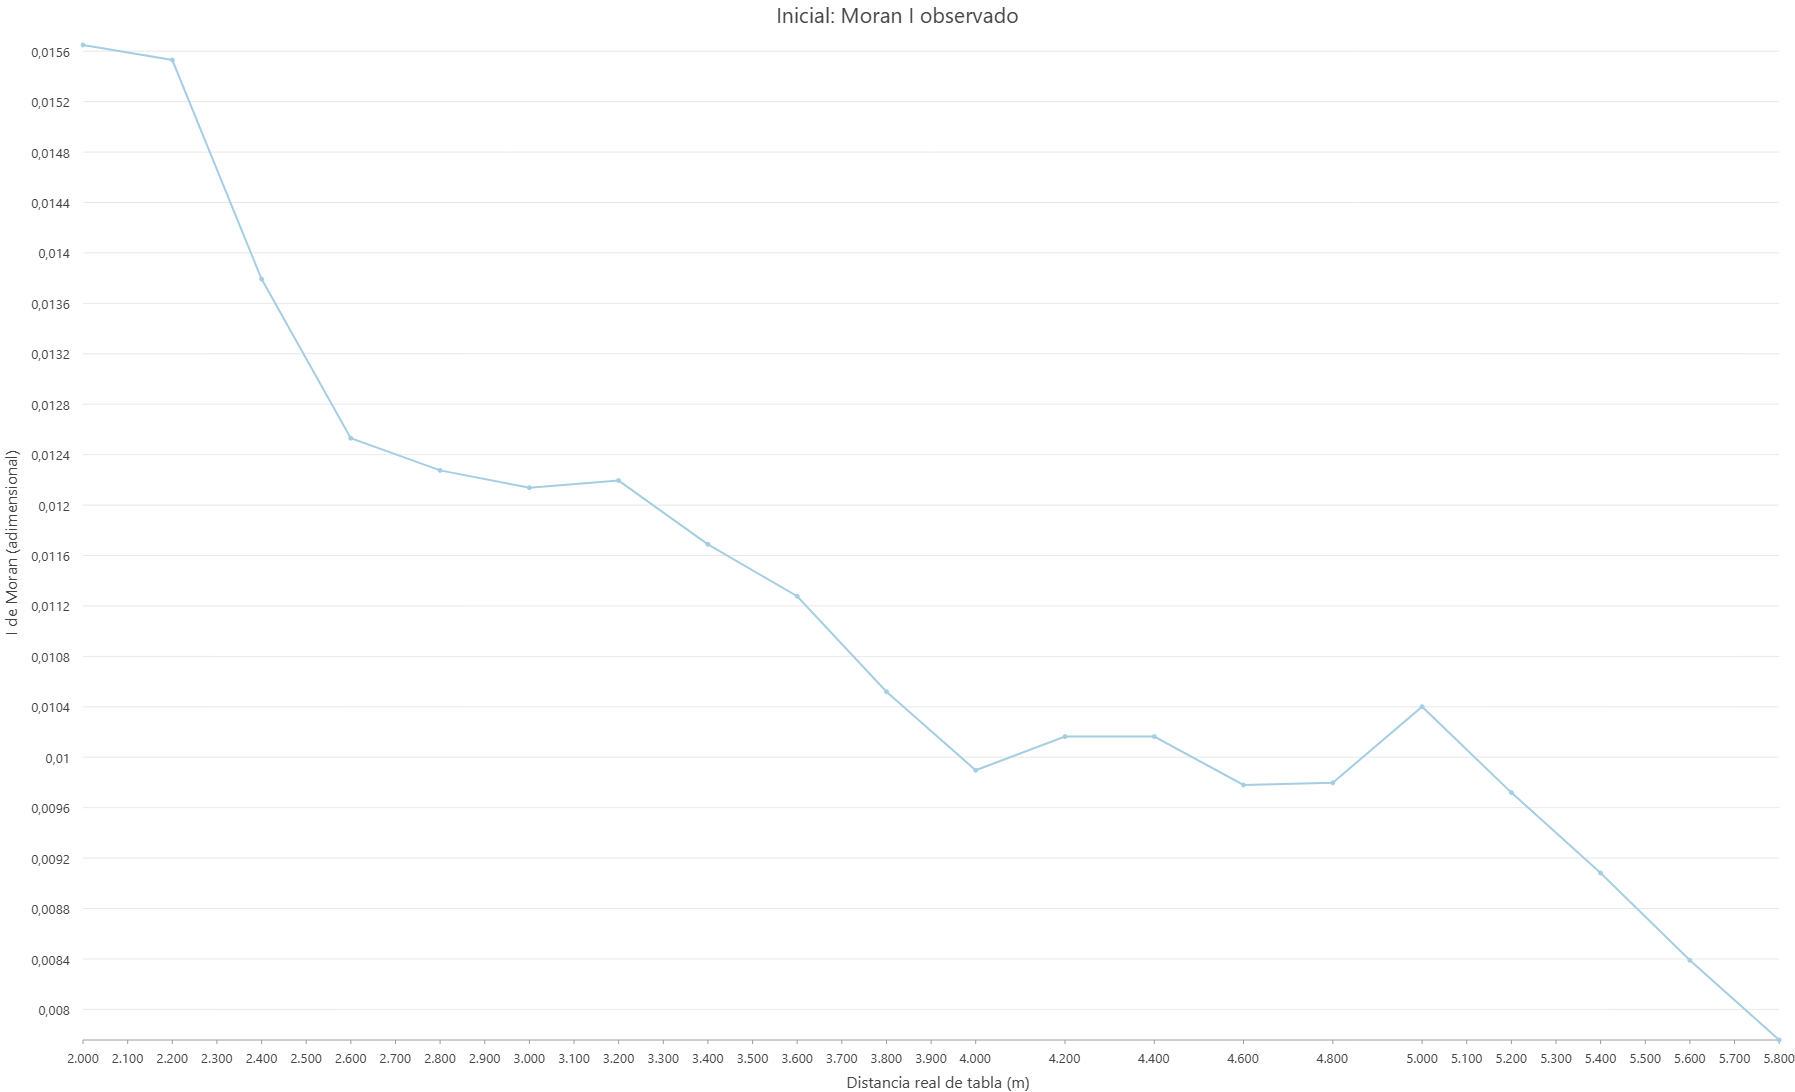

In [30]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
field='MoransI'
chart_png(arcpy.charts.Line(x='Distance', y=field, dataSource=table, title=name + ': ' + {'MoransI':'Moran I observado', 'z_score':'Separación estandarizada respecto al azar', 'p_value':'Valor p nominal'}[field], xTitle='Distancia real de tabla (m)', yTitle={'MoransI':'I de Moran (adimensional)', 'z_score':'z (desviaciones estándar bajo H₀)', 'p_value':'p nominal (no P de H₀)'}[field]), name + '_' + field)


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es I (magnitud adimensional), no probabilidad.

I disminuye en general: pasa de 0.015649 a 2 000 m a 0.007757 a 5 800 m, con pequeños repuntes. Sigue siendo positivo; ampliar la vecindad no aumenta necesariamente la semejanza medida.

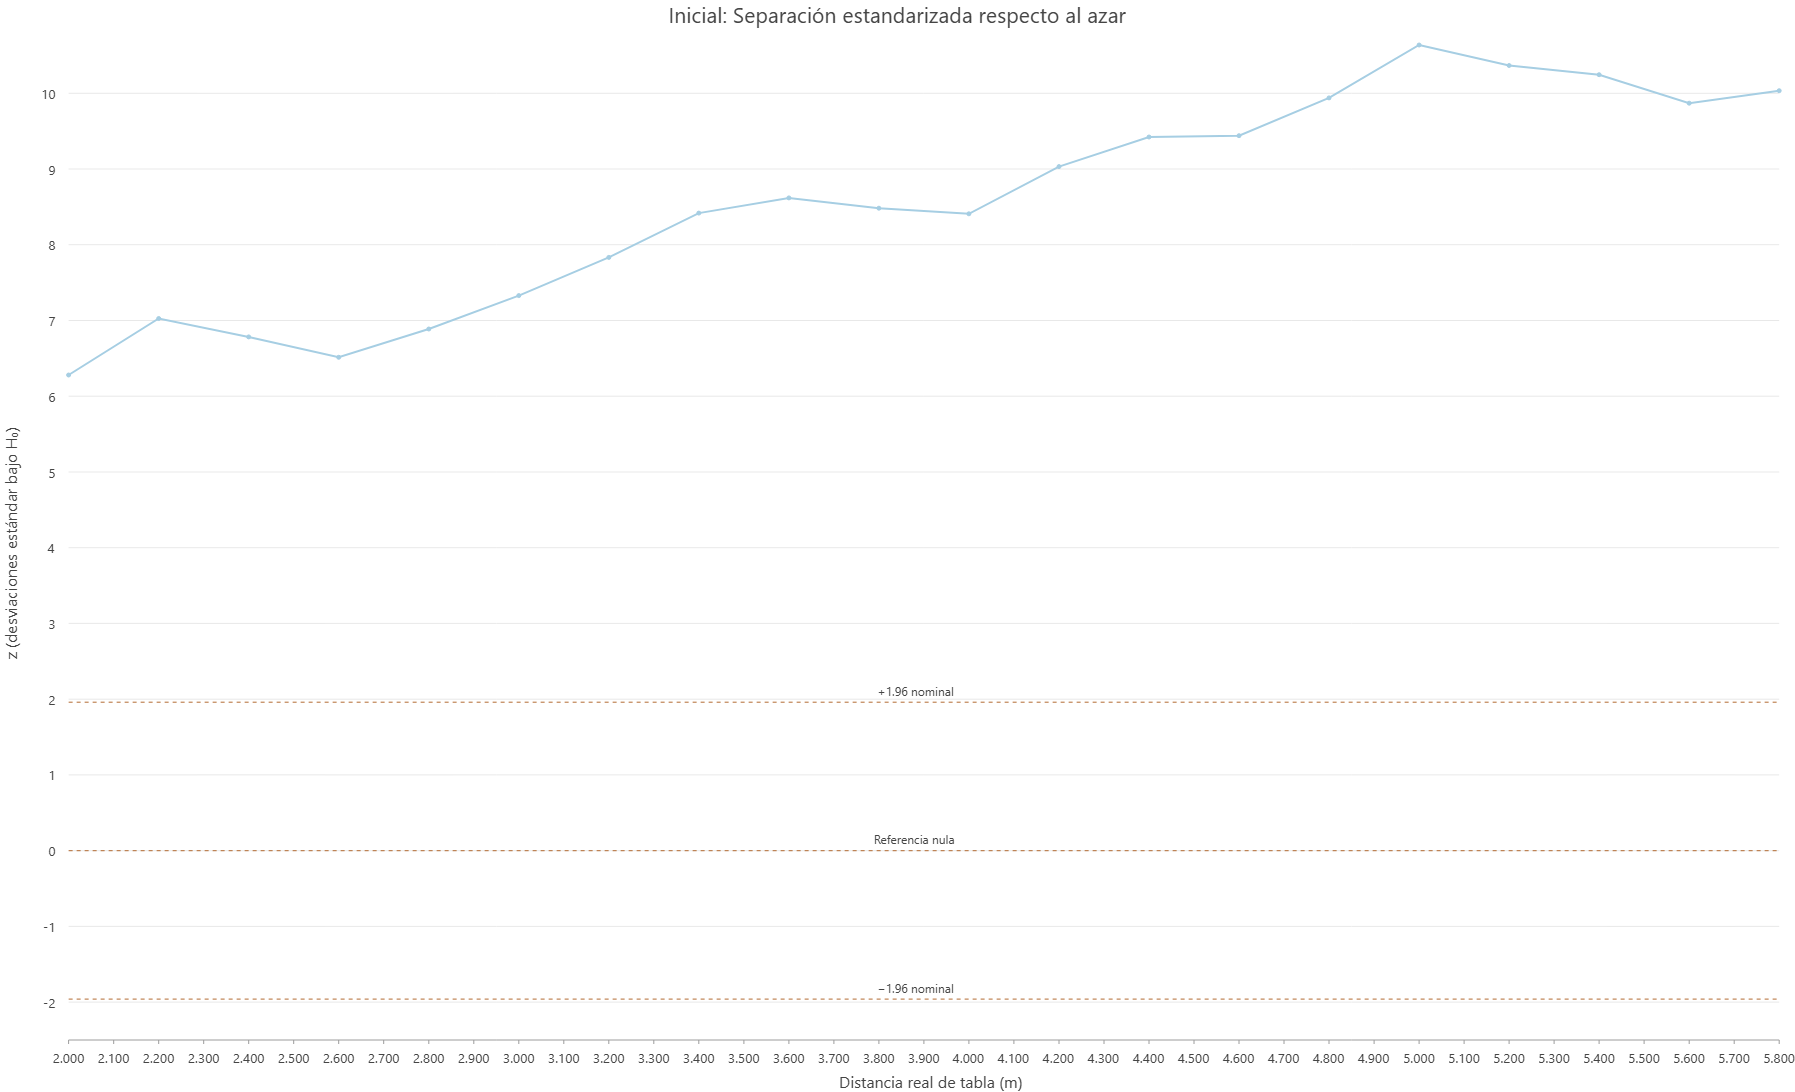

In [31]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
field='z_score'
chart_png(arcpy.charts.Line(x='Distance', y=field, dataSource=table, title=name + ': ' + {'MoransI':'Moran I observado', 'z_score':'Separación estandarizada respecto al azar', 'p_value':'Valor p nominal'}[field], xTitle='Distancia real de tabla (m)', yTitle={'MoransI':'I de Moran (adimensional)', 'z_score':'z (desviaciones estándar bajo H₀)', 'p_value':'p nominal (no P de H₀)'}[field]), name + '_' + field)


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es z (desviaciones bajo H₀); ±1.96 son referencias nominales.

z sube con oscilaciones desde 6.280796 hasta su máximo de 10.637299 a 5 000 m; luego baja en general. Aunque I tiende a disminuir, z puede aumentar porque también cambia la varianza bajo H₀. El pico no señala por sí solo la mejor distancia.

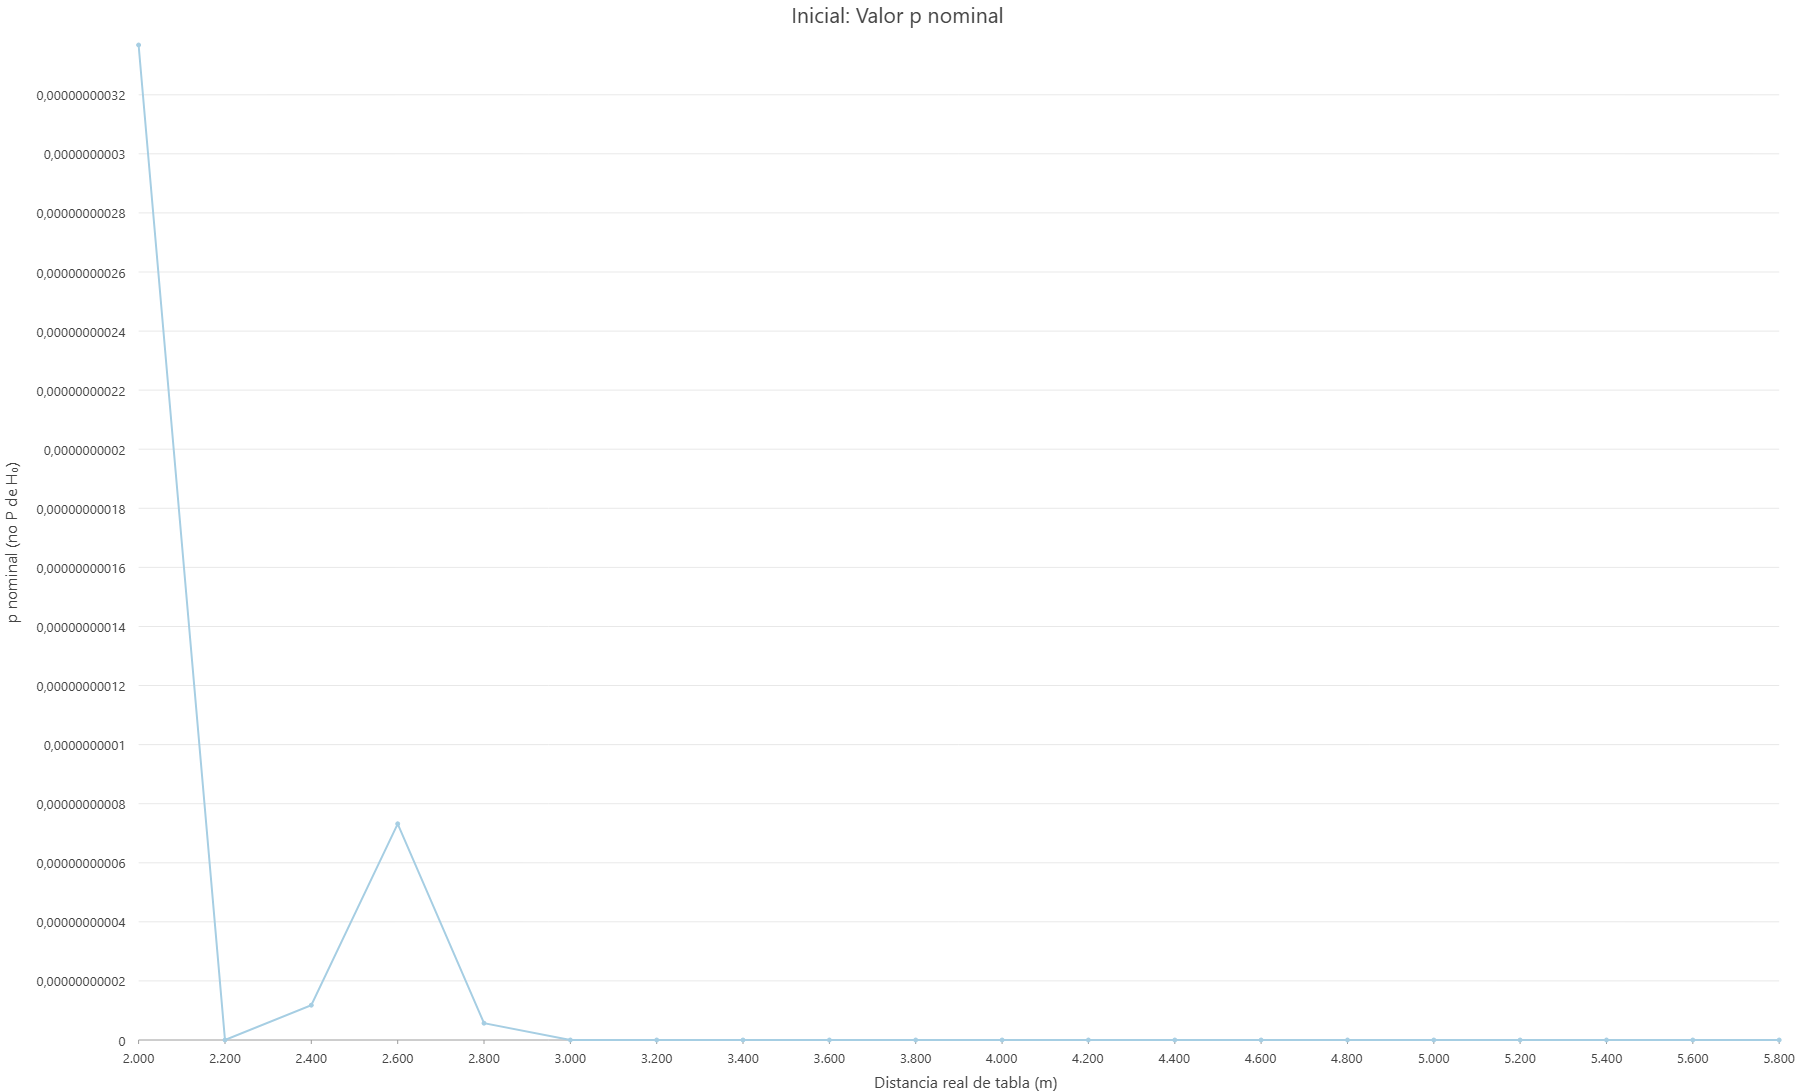

In [32]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
field='p_value'
chart_png(arcpy.charts.Line(x='Distance', y=field, dataSource=table, title=name + ': ' + {'MoransI':'Moran I observado', 'z_score':'Separación estandarizada respecto al azar', 'p_value':'Valor p nominal'}[field], xTitle='Distancia real de tabla (m)', yTitle={'MoransI':'I de Moran (adimensional)', 'z_score':'z (desviaciones estándar bajo H₀)', 'p_value':'p nominal (no P de H₀)'}[field]), name + '_' + field)


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es p nominal, no P(H₀); un cero mostrado refleja precisión numérica.

En esta escala lineal, los valores p muy pequeños quedan casi pegados a cero. La tabla distingue, por ejemplo, 3.37×10⁻¹⁰ a 2 000 m y 1.18×10⁻¹¹ a 2 400 m, además de ceros numéricos. Una curva casi plana no demuestra valores idénticos entre bandas.

### Calcular incremental Segunda

Ampliamos el intervalo a 1 000–6 800 m: añadimos vecindades menores que 2 000 m y mayores que 5 800 m, manteniendo el paso de 200 m. Así vemos qué ocurre fuera del primer intervalo, sin elegir una banda ganadora ni tratar esta segunda mirada como validación independiente.

ICOUNT; 30 bandas; inicio 1000 m, paso 200 m; final solicitado 6800 m. EUCLIDEAN / ROW_STANDARDIZATION. Radios acumulativos, no anillos. Diseño distinto de la distancia inversa global; no confirmación independiente. Registrar distancias reales y posibles ajustes.

In [33]:
# Evaluar bandas previstas y conservar distancias reales y mensajes completos.
name='Segunda';bands=30;beginning=1000;step=200
table = str(Path(gdb) / ('Incremental_' + name))
report = str(run / ('incremental_' + name + '.pdf'))
result = gp_child('IncrementalSpatialAutocorrelation', weighted, 'ICOUNT', bands, beginning, step, 'EUCLIDEAN', 'ROW_STANDARDIZATION', table, report)
print(name, 'solicitado:', bands, beginning, step, result['messages'])
columns = ['Distance', 'MoransI', 'ExpectedI', 'Variance', 'z_score', 'p_value']
if not set(columns).issubset({f.name for f in arcpy.ListFields(table)}):
    raise ValueError('Esquema incremental inesperado; revisar sin inventar campos.')
with arcpy.da.SearchCursor(table, columns) as cursor:
    rows = sorted(list(cursor))
print(columns)
for row in rows:
    print(row)

# Descargar los bytes reales del PDF; alternativa local si el navegador lo bloquea.
import base64
payload = base64.b64encode(Path(report).read_bytes()).decode('ascii')
display(HTML(f'<a download="{Path(report).name}" href="data:application/pdf;base64,{payload}">Descargar informe incremental PDF</a>'))
print('Alternativa local:', report, '| interacción de descarga no comprobada')


Hijo IncrementalSpatialAutocorrelation PID 61700 | diario: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\IncrementalSpatialAutocorrelation_5745aee2e563\process.json


Cierre natural del hijo: 0 | logs: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\IncrementalSpatialAutocorrelation_5745aee2e563


Segunda solicitado: 30 1000 200 Start Time: martes, 22 de septiembre de 2026 2:42:44 p. m.



            Global Moran's I Summary by Distance            
Distance Moran's Index Expected Index Variance   z-score  p-value
 1000.00      0.020779      -0.000344 0.000021  4.570854 0.000005
 1200.00      0.019181      -0.000343 0.000016  4.953125 0.000001
 1400.00      0.018458      -0.000343 0.000012  5.447021 0.000000
 1600.00      0.016049      -0.000343 0.000010  5.282587 0.000000
 1800.00      0.015666      -0.000343 0.000008  5.748918 0.000000
 2000.00      0.015649      -0.000343 0.000006  6.280796 0.000000
 2200.00      0.015530      -0.000343 0.000005  7.026597 0.000000
 2400.00      0.013792      -0.000343 0.000004  6.782965 0.000000
 2600.00      0.012530      -0.000343 0.000004  6.513977 0.000000
 2800.00      0.012275      -0.000343 0.000003  6.887377 0.000000
 3000.00      0.012138      -0.000343 0.000003  7.328451 0.000000
 3200.00      0.012194      -0.000343 0.000003  7.833

['Distance', 'MoransI', 'ExpectedI', 'Variance', 'z_score', 'p_value']
(1000.0, 0.020779413499073064, -0.00034352456200618345, 2.1355707499797346e-05, 4.57085393821767, 4.857407663453691e-06)
(1200.0, 0.019181057256664556, -0.00034328870580157915, 1.5537976244639477e-05, 4.953124769038338, 7.303111380018595e-07)
(1400.0, 0.01845786567833508, -0.00034317089910775565, 1.1913669043747752e-05, 5.447020736694928, 5.1220493730301814e-08)
(1600.0, 0.01604871372505591, -0.00034317089910775565, 9.628629381758074e-06, 5.282586940086968, 1.2737235597642051e-07)
(1800.0, 0.015666174645159073, -0.00034305317324185246, 7.754762851541937e-06, 5.748918134560664, 8.981629006253636e-09)
(2000.0, 0.01564919659283359, -0.00034305317324185246, 6.483205104734965e-06, 6.28079593542964, 3.3684403661651133e-10)
(2200.0, 0.015530235724041282, -0.00034305317324185246, 5.103213028578472e-06, 7.0265974155865205, 0.0)
(2400.0, 0.013792176115114307, -0.0003429355281207133, 4.342695648076356e-06, 6.782964533962335, 1

Alternativa local: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\incremental_Segunda.pdf | interacción de descarga no comprobada


Segunda conserva 30 bandas, 1 000–6 800 m. Primer pico a 1 400 m (z=5.447021); máximo pico a 5 000 m (z=10.637299). La coincidencia con Inicial no valida independientemente una escala: usa los mismos sitios.

I resume productos de desviaciones entre vecinos. z=(I−E[I])/√Var₀(I), varianza del estadístico bajo H₀, no de distancias. p no es P(H₀); conservar todas las bandas y mensajes.

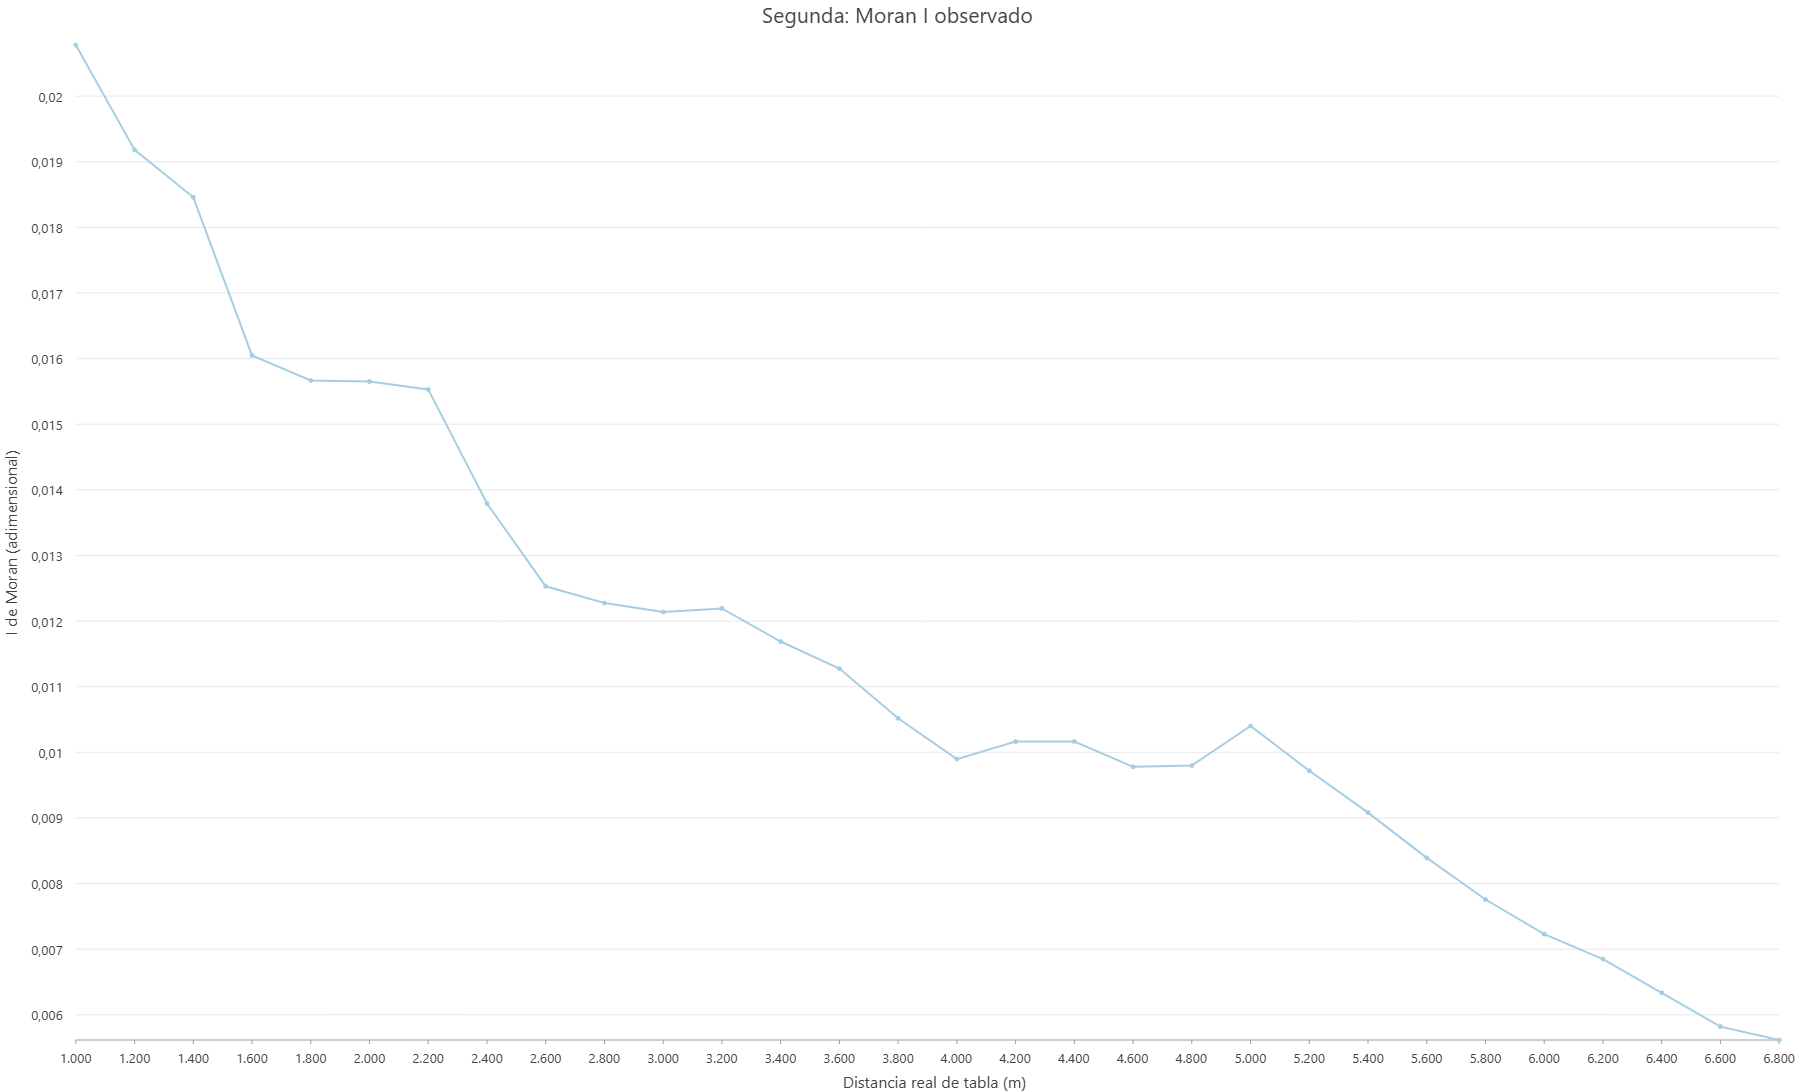

In [34]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
field='MoransI'
chart_png(arcpy.charts.Line(x='Distance', y=field, dataSource=table, title=name + ': ' + {'MoransI':'Moran I observado', 'z_score':'Separación estandarizada respecto al azar', 'p_value':'Valor p nominal'}[field], xTitle='Distancia real de tabla (m)', yTitle={'MoransI':'I de Moran (adimensional)', 'z_score':'z (desviaciones estándar bajo H₀)', 'p_value':'p nominal (no P de H₀)'}[field]), name + '_' + field)


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es I (magnitud adimensional), no probabilidad.

La tendencia descendente se mantiene en el intervalo ampliado: I pasa de 0.020779 a 1 000 m a 0.005616 a 6 800 m. Hay repuntes intermedios, no una caída uniforme; los valores siguen siendo positivos.

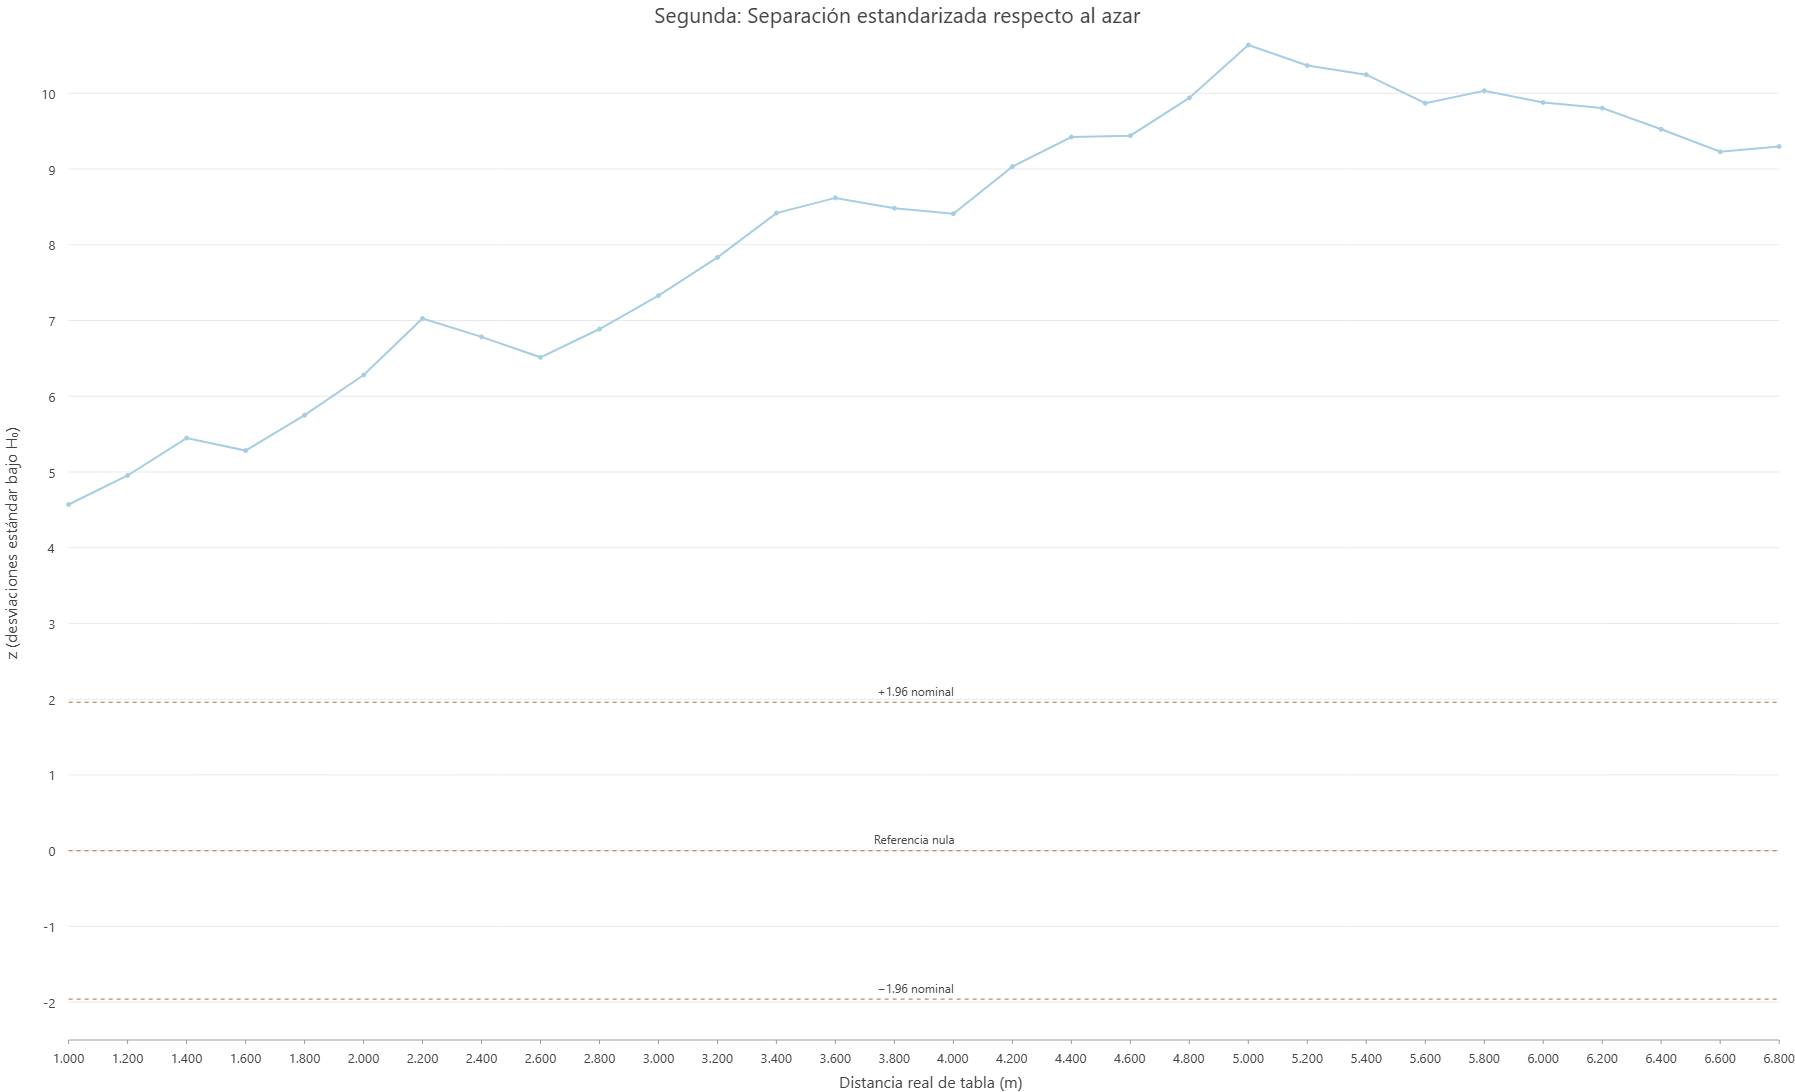

In [35]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
field='z_score'
chart_png(arcpy.charts.Line(x='Distance', y=field, dataSource=table, title=name + ': ' + {'MoransI':'Moran I observado', 'z_score':'Separación estandarizada respecto al azar', 'p_value':'Valor p nominal'}[field], xTitle='Distancia real de tabla (m)', yTitle={'MoransI':'I de Moran (adimensional)', 'z_score':'z (desviaciones estándar bajo H₀)', 'p_value':'p nominal (no P de H₀)'}[field]), name + '_' + field)


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es z (desviaciones bajo H₀); ±1.96 son referencias nominales.

z parte de 4.570854 a 1 000 m, alcanza de nuevo su máximo de 10.637299 a 5 000 m y termina en 9.297020 a 6 800 m. La subida y bajada tienen oscilaciones. El máximo de z no coincide con el mayor I: magnitud y separación respecto a H₀ responden preguntas distintas.

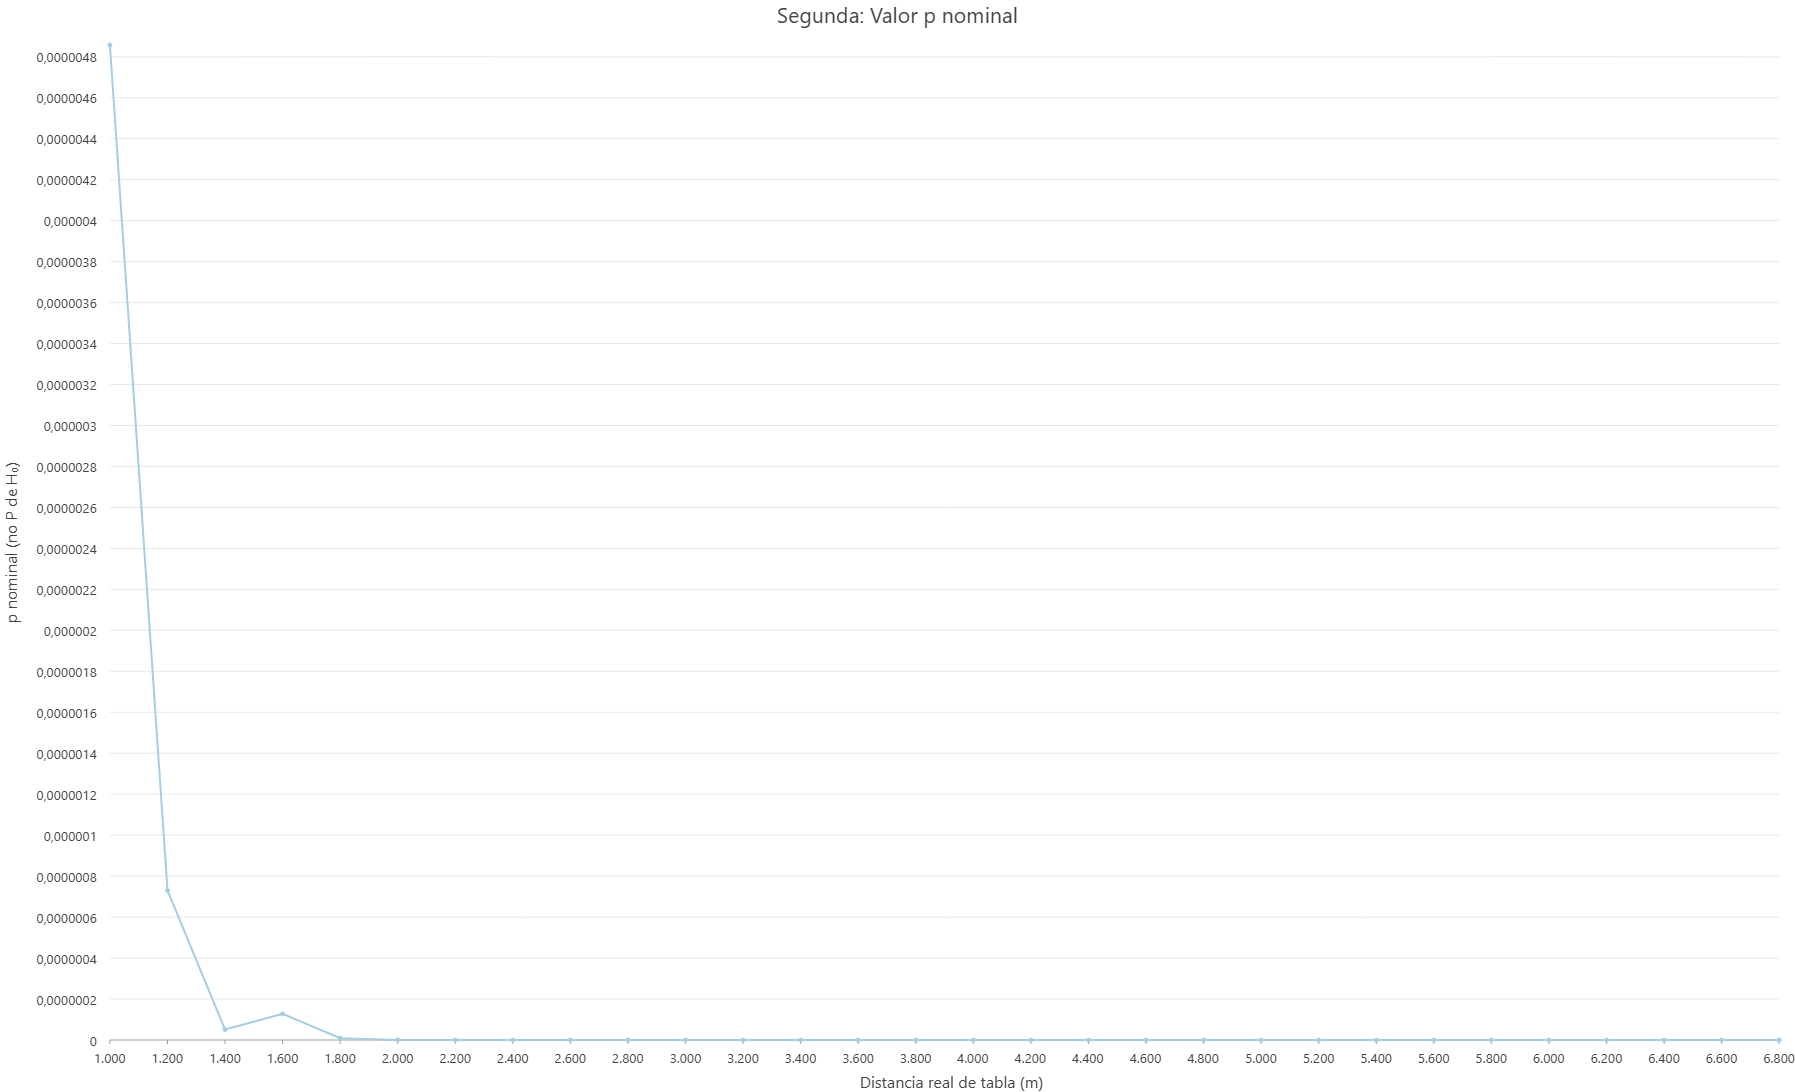

In [36]:
# Representar la medida indicada frente a distancia real, no seleccionar solo el menor p.
field='p_value'
chart_png(arcpy.charts.Line(x='Distance', y=field, dataSource=table, title=name + ': ' + {'MoransI':'Moran I observado', 'z_score':'Separación estandarizada respecto al azar', 'p_value':'Valor p nominal'}[field], xTitle='Distancia real de tabla (m)', yTitle={'MoransI':'I de Moran (adimensional)', 'z_score':'z (desviaciones estándar bajo H₀)', 'p_value':'p nominal (no P de H₀)'}[field]), name + '_' + field)


Curva ArcGIS, elaboración docente con la tabla de esta corrida: x es distancia cartográfica real; y es p nominal, no P(H₀); un cero mostrado refleja precisión numérica.

p pasa de aproximadamente 4.86×10⁻⁶ a 1 000 m a 7.30×10⁻⁷ a 1 200 m y permanece muy pequeño, con oscilaciones y ceros numéricos. La escala lineal aplana los valores más pequeños: parecer iguales no significa serlo. Consulte la tabla antes de comparar bandas.

## Complemento solicitado: Getis-Ord Gi* (no mostrado en la grabación)
Moran resume la asociación global. Ahora preguntamos **dónde se agrupan conteos altos o bajos**. Gi* compara cada sitio con sus vecinos; un conteo alto aislado no basta para formar un punto caliente.

Usamos ICOUNT, los ocho vecinos más cercanos (k=8), distancia euclidiana y FDR. Esri recomienda aproximadamente ocho vecinos con asimetría. Fijamos k antes de ver resultados: la distancia varía entre sitios y no usamos un pico incremental como radio. `NONE` es un parámetro heredado sin efecto.

Se requieren al menos 30 sitios y variación finita. Conservamos WKID=3857: Web Mercator distorsiona distancias y vecindades, por lo que la interpretación es exploratoria. HotSpots crea Gi_8vecinos_FDR con z, p nominal y categoría FDR, sin mover, reparar ni eliminar sitios.

**Fuente complementaria:** Esri, ArcGIS Pro 3.6, [Hot Spot Analysis: Usage/Parameters/Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/hot-spot-analysis.htm) y [How Hot Spot Analysis works](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/h-how-hot-spot-analysis-getis-ord-gi-spatial-stati.htm), consulta 2026-09-16. Firma contrastada con Pro 3.6.2 instalado.

**Lectura de Gi\*:** combina valor del sitio y vecinos; k=8 fija vecinos, no radio físico. GiZScore es separación estandarizada (positivo: concentración alta; negativo: baja); GiPValue es p crudo, no probabilidad de riesgo. Gi_Bin usa FDR: ±1/±2/±3 son categorías 90/95/99 %, con signo caliente/frío; 0=no significativo, no prueba de azar ni lugar seguro. FDR ajusta múltiples contrastes locales, no selección de modelo, k o escala después de ver resultados.

In [37]:
# Configuración fijada antes de observar resultados; entradas de solo lectura.
import inspect, json
print('Firma instalada:', inspect.signature(arcpy.stats.HotSpots))
assert 'number_of_neighbors' in inspect.signature(arcpy.stats.HotSpots).parameters
if n_sites < 30 or n_sites <= 8 or len(set(icount)) < 2 or not all(math.isfinite(v) for v in icount):
    raise ValueError('Gi* requiere al menos 30 sitios, más de ocho, valores finitos y variación.')
if sr.type != 'Projected' or sr.linearUnitName.lower() not in ('meter','metre'):
    raise ValueError('Revisar CRS y extensión: no proyectar automáticamente.')
hotspots = str(Path(gdb) / 'Gi_8vecinos_FDR')
gi_result = gp_child('HotSpots', 
    Input_Feature_Class=weighted, Input_Field='ICOUNT', Output_Feature_Class=hotspots,
    Conceptualization_of_Spatial_Relationships='K_NEAREST_NEIGHBORS',
    Distance_Method='EUCLIDEAN_DISTANCE', Standardization='NONE',
    Apply_False_Discovery_Rate__FDR__Correction='APPLY_FDR', number_of_neighbors=8,
)
print(gi_result['messages'])
(run / 'Gi_mensajes.txt').write_text(gi_result['messages'], encoding='utf-8')
with arcpy.da.SearchCursor(hotspots, ['Gi_Bin']) as cursor:
    gi_counts = Counter(int(row[0]) for row in cursor)
assert sum(gi_counts.values()) == n_sites
labels = {-3:'Frío 99%', -2:'Frío 95%', -1:'Frío 90%', 0:'No significativo', 1:'Caliente 90%', 2:'Caliente 95%', 3:'Caliente 99%'}
tabla_visible(['Gi_Bin (FDR)', 'Categoría', 'Sitios'], [[v, labels[v], gi_counts[v]] for v in range(-3,4)])
tabla_visible(['Campo real', 'Significado', 'Lectura y límite'], [
    ['GiZScore', 'Estadístico local estandarizado', 'Positivo/negativo: valores altos/bajos agrupados, no riesgo'],
    ['GiPValue', 'p nominal sin corrección FDR', 'Extremidad bajo el modelo nulo; no probabilidad de H0'],
    ['Gi_Bin', 'Clasificación FDR: ±1/±2/±3 y 0', 'Frío/caliente; 90/95/99%; 0 no significativo'],
    ['SOURCE_ID', 'Enlace al identificador local de entrada', 'No clave semántica ni prueba de duplicación'],
    ['ICOUNT', 'Registros por sitio ocupado', 'No ausencia territorial, exposición ni tasa'],
])
(run / 'Gi_conteos.json').write_text(json.dumps({str(v):gi_counts[v] for v in range(-3,4)}, indent=2), encoding='utf-8')


Firma instalada: (Input_Feature_Class=None, Input_Field=None, Output_Feature_Class=None, Conceptualization_of_Spatial_Relationships: "Literal['INVERSE_DISTANCE', 'INVERSE_DISTANCE_SQUARED', 'FIXED_DISTANCE_BAND', 'ZONE_OF_INDIFFERENCE', 'K_NEAREST_NEIGHBORS', 'CONTIGUITY_EDGES_ONLY', 'CONTIGUITY_EDGES_CORNERS', 'GET_SPATIAL_WEIGHTS_FROM_FILE'] | None" = None, Distance_Method: "Literal['EUCLIDEAN_DISTANCE', 'MANHATTAN_DISTANCE'] | None" = None, Standardization: "Literal['NONE', 'ROW'] | None" = None, Distance_Band_or_Threshold_Distance=None, Self_Potential_Field=None, Weights_Matrix_File=None, Apply_False_Discovery_Rate__FDR__Correction: "Literal['APPLY_FDR', 'NO_FDR'] | None" = None, number_of_neighbors=None) -> 'Result'
Hijo HotSpots PID 66452 | diario: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\HotSpots_d3b7929694a9\process.json


Cierre natural del hijo: 0 | logs: ../../99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\ejecucion_e4c744c9e69c\gp_children\HotSpots_d3b7929694a9


Start Time: martes, 22 de septiembre de 2026 2:44:04 p. m.
Succeeded at martes, 22 de septiembre de 2026 2:44:12 p. m. (Elapsed Time: 7.56 seconds)


Gi_Bin (FDR),Categoría,Sitios
-3,Frío 99%,0
-2,Frío 95%,0
-1,Frío 90%,0
0,No significativo,2802
1,Caliente 90%,18
2,Caliente 95%,18
3,Caliente 99%,81


Campo real,Significado,Lectura y límite
GiZScore,Estadístico local estandarizado,"Positivo/negativo: valores altos/bajos agrupados, no riesgo"
GiPValue,p nominal sin corrección FDR,Extremidad bajo el modelo nulo; no probabilidad de H0
Gi_Bin,Clasificación FDR: ±1/±2/±3 y 0,Frío/caliente; 90/95/99%; 0 no significativo
SOURCE_ID,Enlace al identificador local de entrada,No clave semántica ni prueba de duplicación
ICOUNT,Registros por sitio ocupado,"No ausencia territorial, exposición ni tasa"


81

### Leer el mapa de Gi*
Gi_Bin clasifica con FDR; GiZScore/GiPValue conservan los valores sin ajustar. SOURCE_ID enlaza la fila local, no certifica una vivienda.

Las barras del panel completo incluyen siete categorías, aun con cero sitios: frío, no significativo (NS) y caliente (Cal), con sus niveles de significancia cuando corresponden. Las categorías se leen mediante las etiquetas y las cantidades de sitios mediante las alturas de las barras; todas las barras guardadas son de color azul claro uniforme, que no codifica significancia. Los colores por categoría corresponden al mapa y se interpretan con su propia leyenda. El panel de detalle excluye NS. Los prefijos 1–7 solo ordenan las categorías.

La leyenda del mapa guardado muestra solo las cuatro categorías presentes: no significativo y caliente al 90/95/99 %. No hay sitios fríos significativos en esta salida. Los niveles 90/95/99 % expresan significancia, no proporciones de sitios ni probabilidades de una causa.

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


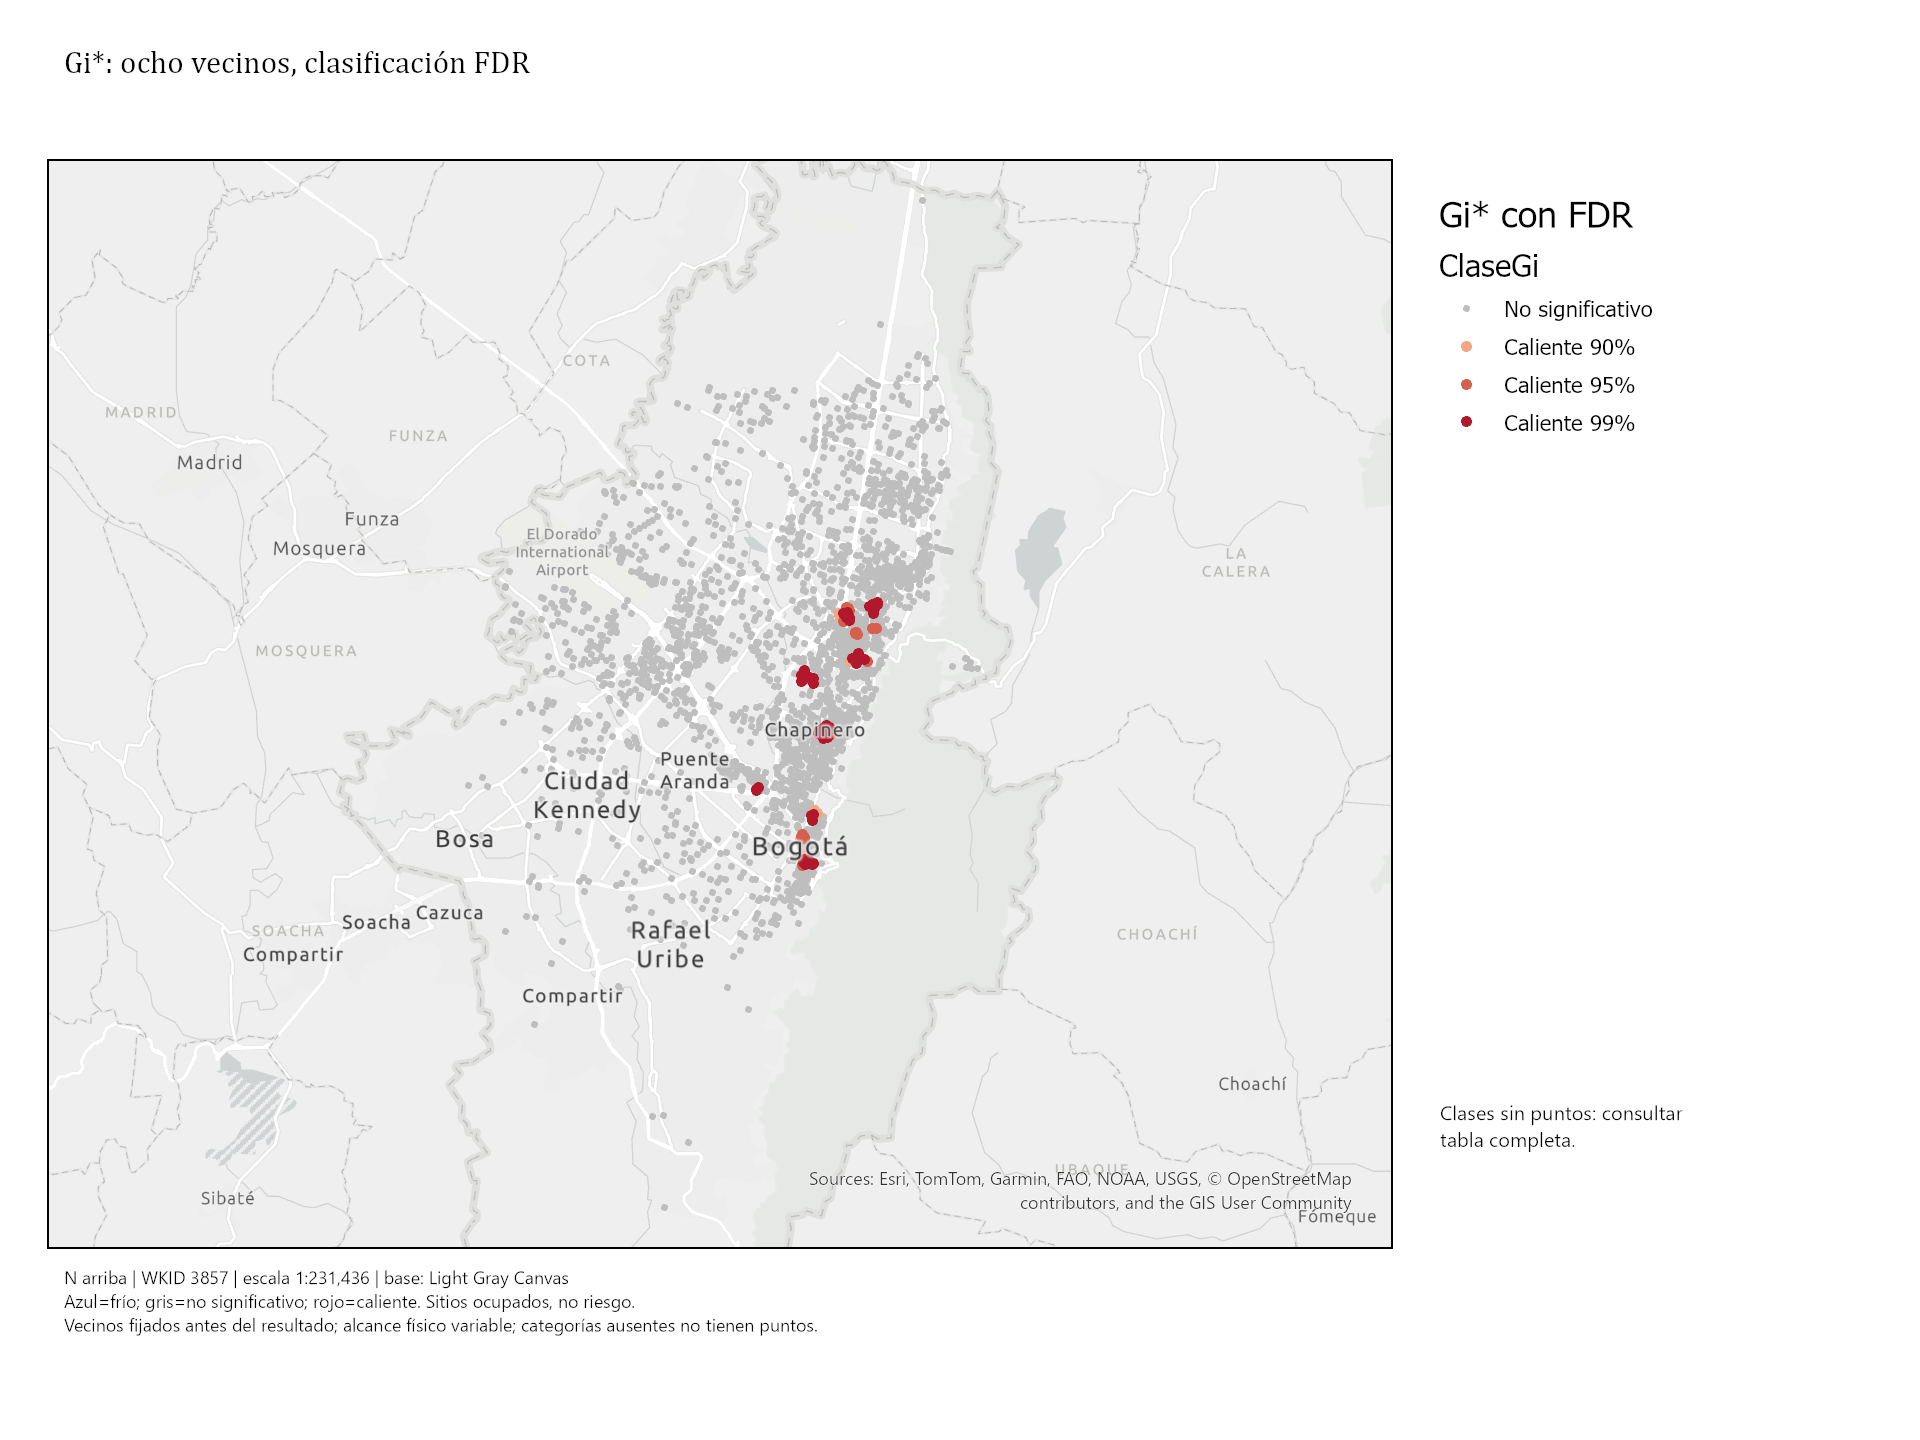

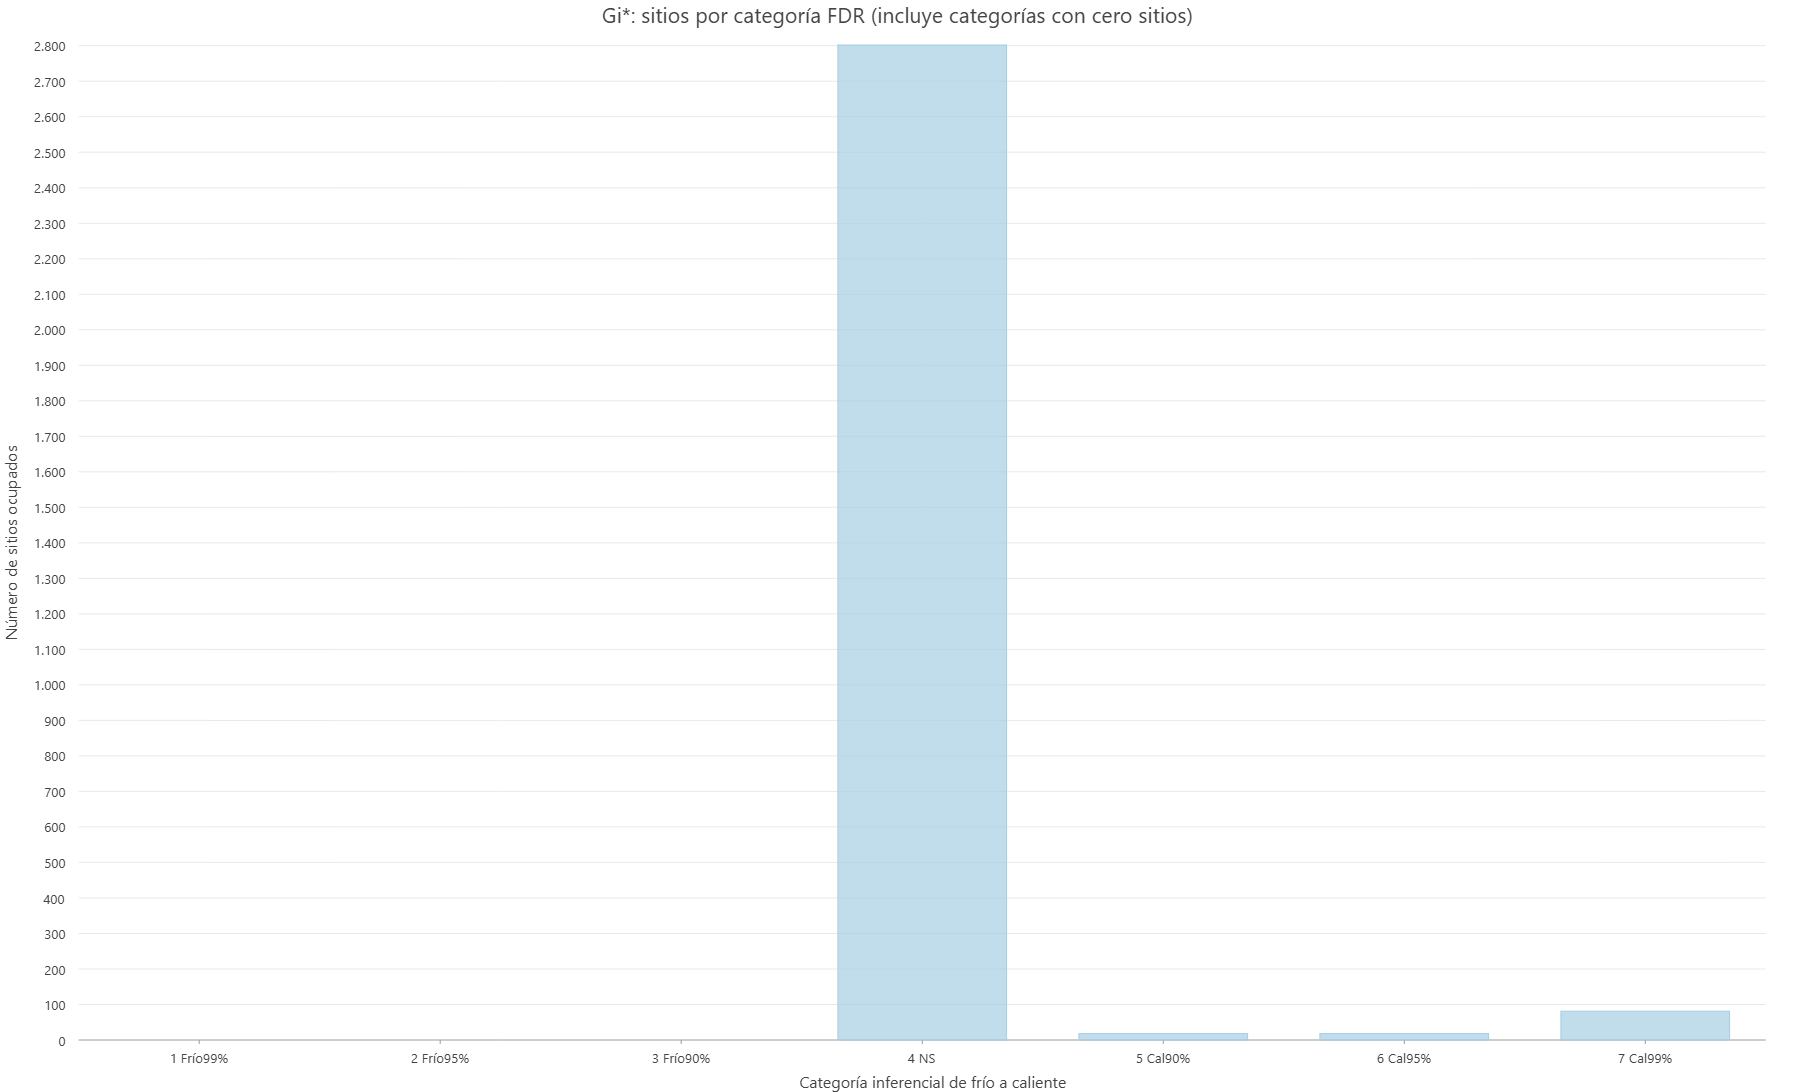

Resultado observado: 0 fríos, 2802 no significativos y 117 calientes. Total=2919.
Categorías vacías son válidas: no se modifica k para obtener colores. Multiplicidad local no equivale a ausencia o riesgo.


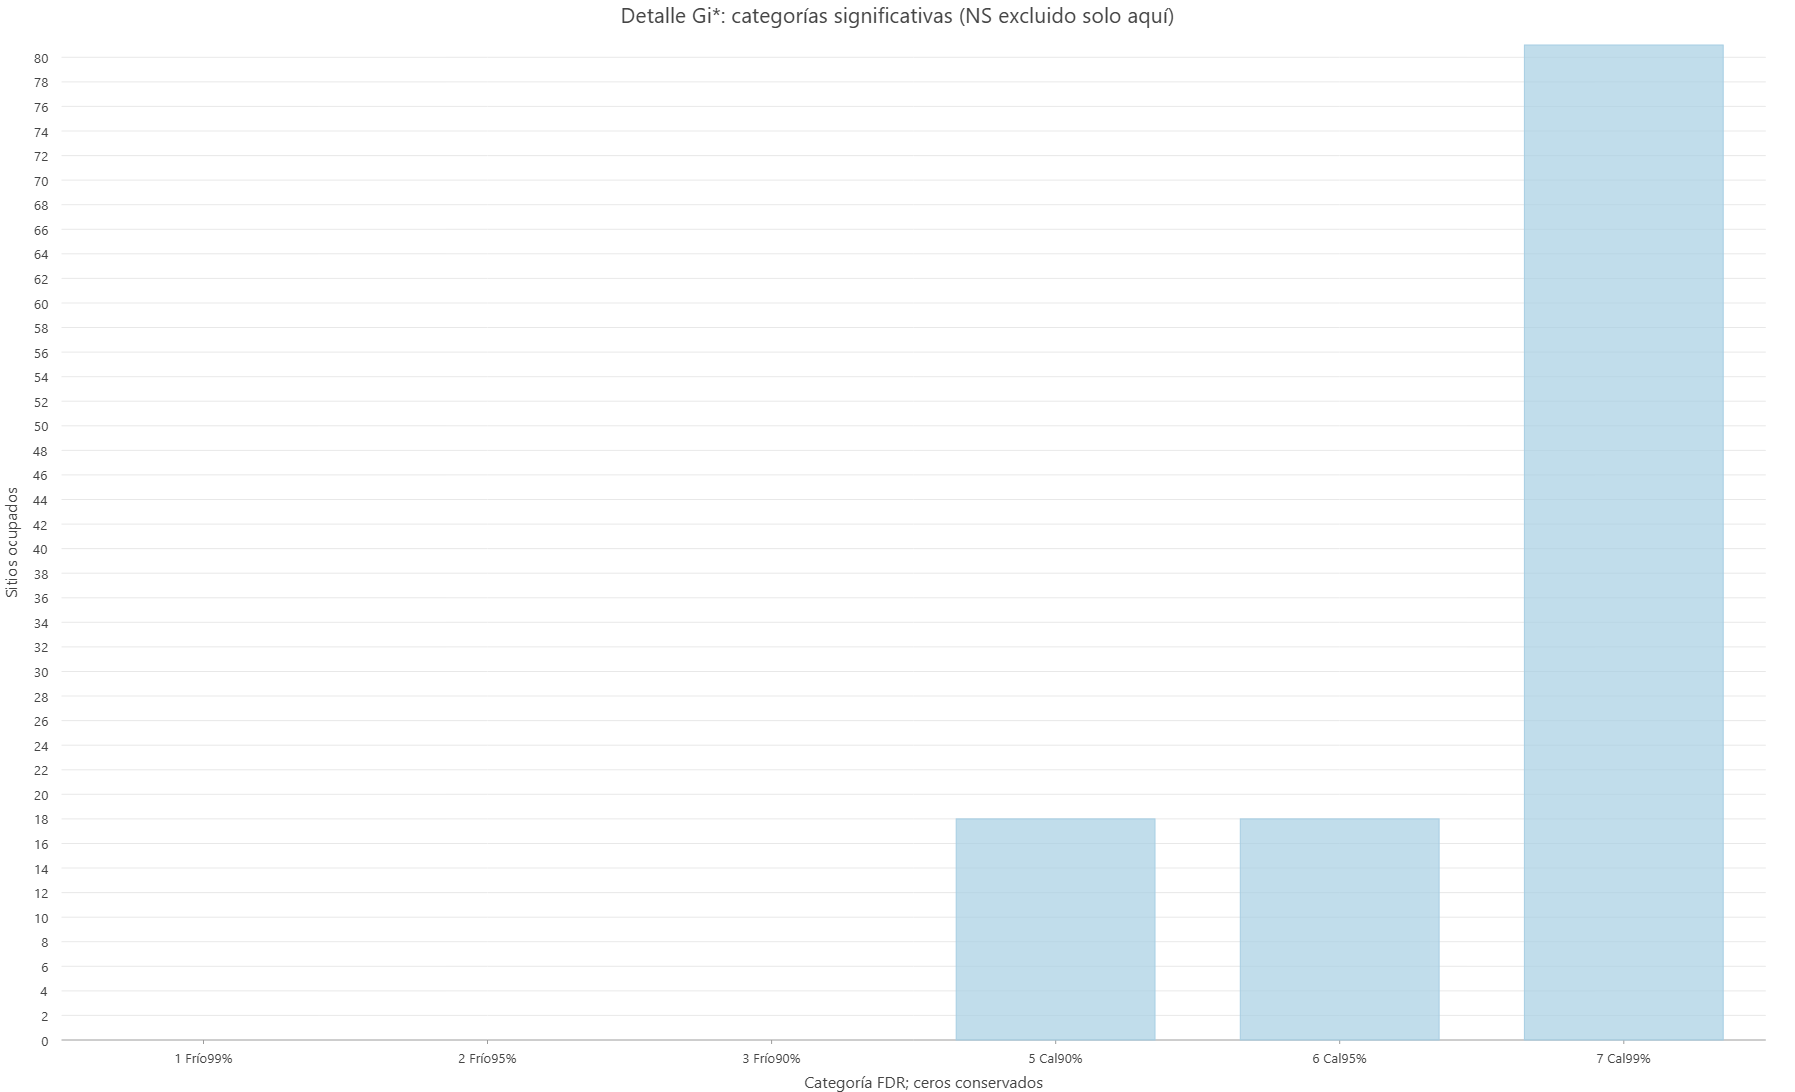

Categoría FDR,Sitios,Total de sitios,Porcentaje del total
Frío 99%,0,2919,0.0
Frío 95%,0,2919,0.0
Frío 90%,0,2919,0.0
No significativo,2802,2919,95.992
Caliente 90%,18,2919,0.617
Caliente 95%,18,2919,0.617
Caliente 99%,81,2919,2.775


Lectura: detalle sin NS para comparar minorías; cero fríos no significa un territorio más seguro.


In [38]:
# Azul-neutral-rojo igual en las tres prácticas; no fabricar categorías presentes.
gi_colors = [[33,102,172,100], [67,147,195,100], [146,197,222,100], [190,190,190,100],
             [244,165,130,100], [214,96,77,100], [178,24,43,100]]
arcpy.management.AddField(hotspots, 'ClaseGi', 'TEXT', field_length=40)
with arcpy.da.UpdateCursor(hotspots, ['Gi_Bin','ClaseGi']) as cursor:
    for row in cursor:
        row[1] = str(int(row[0])+4) + '. ' + labels[int(row[0])]
        cursor.updateRow(row)
gi_styles = {str(v+4)+'. '+labels[v]:(labels[v], gi_colors[v+3], 3 if v == 0 else 5) for v in range(-3,4)}
mapa_categorias(hotspots, 'ClaseGi', 'mapa_Gi_FDR', 'Gi*: ocho vecinos, clasificación FDR', gi_styles,
    'Azul=frío; gris=no significativo; rojo=caliente. Sitios ocupados, no riesgo.' + chr(10) +
    'Vecinos fijados antes del resultado; alcance físico variable; categorías ausentes no tienen puntos.')
short_labels = ['1 Frío99%', '2 Frío95%', '3 Frío90%', '4 NS', '5 Cal90%', '6 Cal95%', '7 Cal99%']
gi_table = tabla_frecuencia('Frecuencia_Gi', [(short_labels[v+3],gi_counts[v]) for v in range(-3,4)])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=gi_table,
    title='Gi*: sitios por categoría FDR (incluye categorías con cero sitios)',
    xTitle='Categoría inferencial de frío a caliente', yTitle='Número de sitios ocupados'), 'barras_Gi_FDR')
cold = sum(gi_counts[v] for v in (-3,-2,-1))
hot = sum(gi_counts[v] for v in (1,2,3))
print(f'Resultado observado: {cold} fríos, {gi_counts[0]} no significativos y {hot} calientes. Total={n_sites}.')
print('Categorías vacías son válidas: no se modifica k para obtener colores. Multiplicidad local no equivale a ausencia o riesgo.')

# Detalle explícito: seis categorías significativas; NS permanece en el panel completo.
gi_detalle = tabla_frecuencia('Frecuencia_Gi_detalle',
    [(short_labels[v+3], gi_counts[v]) for v in (-3,-2,-1,1,2,3)])
chart_png(arcpy.charts.Bar(x='Categoria', y='Sitios', aggregation='SUM', dataSource=gi_detalle,
    title='Detalle Gi*: categorías significativas (NS excluido solo aquí)',
    xTitle='Categoría FDR; ceros conservados', yTitle='Sitios ocupados'), 'barras_Gi_detalle')
tabla_visible(['Categoría FDR', 'Sitios', 'Total de sitios', 'Porcentaje del total'],
    [[labels[v], gi_counts[v], n_sites, round(100*gi_counts[v]/n_sites, 3)] for v in range(-3,4)])
print('Lectura: detalle sin NS para comparar minorías; cero fríos no significa un territorio más seguro.')


## Conclusiones

Hay 18/18/81 sitios calientes al 90/95/99 % y 2 802 no significativos. No hay fríos significativos. El gris no prueba azar ni seguridad; el rojo no explica causas. Mapas y barras: elaboración docente con ArcGIS Pro 3.6.2 sobre la copia local citada, no datos sintéticos.

Los grupos rojos de Gi* se observan principalmente hacia el lado oriental (derecho) del encuadre, donde el mapa descriptivo también muestra varios conteos altos. No todo sitio de conteo alto resulta caliente: Gi* considera su vecindad. Estas imágenes no delimitan municipios ni explican por qué aparece el patrón.

Un z grande con I pequeño no representa un efecto económico grande. Un p mostrado como cero está limitado por precisión numérica, no demuestra certeza. Compare las escalas completas, no solo la banda más llamativa. Gi* clasifica multiplicidad local sobre sitios ocupados: no identifica ausencia de turismo, seguridad ni causa. FDR no corrige la selección entre modelos.

Conservamos EPSG:3857 y la secuencia aprobada, sin reproyección: los metros cartográficos no son distancias terrestres certificadas.

<details>
<summary>Historial técnico y evidencias</summary>

## Procedencia y evidencia

**Reejecución técnica del 22/09/2026:** 38/38 celdas completas, cero errores; 16 PNG y dos PDF nativos. Kernel, controlador e hijos terminaron naturalmente con código 0. No se cambió código analítico, orden ni parámetros. Las entradas permanecieron sin cambios. Se conservan advertencias estadísticas y la advertencia del controlador zmq/Proactor. La causa del problema comunicado no quedó identificada: la primera ejecución de Colegios agotó el tiempo de espera después de producir el mapa; las sondas aisladas y esta ejecución completa terminaron correctamente. Los procesos de aquel intento fallido se cerraron por identidad antes de continuar; su evidencia no se reclasifica como éxito. No se certifica el visor Jupyter/VS Code/Obsidian ni se declara la clase completa.

[Registro de esta ejecución](<../../99 - Recursos/salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260922_143758_P03_c04ea9be/result.json>) · [Cierre del controlador](<../../99 - Recursos/salidas_clase_02/correccion_salidas_20260922/controller_P03_ee592be185cf/controller-exit.json>) · [Respaldo anterior](<../../99 - Recursos/salidas_clase_02/correccion_salidas_20260922/revision_2750366f057c/P03_before.ipynb>). Las rutas personales de las salidas textuales se normalizaron después del cierre; los PNG y PDF incrustados conservan sus bytes.

**Informes locales de esta ejecución:** [incremental_Inicial.pdf](<../../99 - Recursos/salidas_clase_02/practica_03/reorganizacion_20260917/ejecucion_e4c744c9e69c/incremental_Inicial.pdf>) · [incremental_Segunda.pdf](<../../99 - Recursos/salidas_clase_02/practica_03/reorganizacion_20260917/ejecucion_e4c744c9e69c/incremental_Segunda.pdf>).

**Los registros siguientes son históricos:** conservan sus cifras y límites originales; no describen las nuevas salidas incrustadas.


**Preparación para publicación:** rutas personales normalizadas a rutas relativas del repositorio, sin reejecutar análisis ni alterar resultados académicos. La evidencia local de ejecución se conserva íntegra en los respaldos; los enlaces a salidas son referencias locales y no todos los archivos auxiliares viajan con Git. Se conservan los PNG y PDF incrustados. El usuario confirmó el permiso de redistribución de mapas y resultados; las restricciones consignadas en los registros anteriores describen su estado histórico.

Datos requeridos: viviendas turísticas Bogotá, Catastro/IDECA, registro administrativo; copia mínima local autorizada disponible. Solo se consultó el endpoint público autorizado al preparar la copia; los análisis usan datos locales; la base cartográfica requiere conexión.
Esri, ArcGIS Pro 3.6, pasajes consultados 2026-09-15: [Collect Events](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/collect-events.htm), Usage/Python; [Incremental Spatial Autocorrelation](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/incremental-spatial-autocorrelation.htm), Usage/Parameters; [cómo funciona incremental](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-incremental-spatial-autocorrelation-works.htm), escala/picos; [cómo funciona Moran global](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/h-how-spatial-autocorrelation-moran-s-i-spatial-st.htm), interpretación. Firma y umbral de global: ayuda instalada `arcpy.stats.SpatialAutocorrelation.__doc__`, Pro 3.6.2, comprobada 2026-09-15; documentación consultada el 2026-09-16: Esri, Pro 3.6, [Spatial Autocorrelation](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/spatial-autocorrelation.htm), Usage/Parameters/Python. Umbral euclidiano vacío garantiza al menos un vecino por entidad; cero, con distancia inversa, significa sin umbral. La firma instalada devuelve Index, ZScore, PValue y Report_File; Index corresponde a Moran I.


### Registro histórico anterior — no describe la ejecución Jupyter guardada

Historia exacta y salidas incrustadas: `99 - Recursos\salidas_clase_02\practica_03\reorganizacion_20260917\historico_88d3979426\Clase 02 - Practica 03 - Viviendas turisticas y Moran.ipynb`. Carpetas previas intactas. Fuente histórica: grabación 14 (2026-06-24), no video de Bomberos del 16/09/2026. La revisión focal histórica no sustituye cobertura actual: video parcial, no clase completa. Data Engineering manual y Jupyter/VS Code/Obsidian no comprobados. Corrida final: 33/33 celdas, 72.011 s, 16 PNG, sin errores de celda; retorno natural 0 observado por el escritor durante la ejecución original, no por el verificador independiente. Salidas: `99 - Recursos/salidas_clase_02/practica_03/reorganizacion_20260917/ejecucion_79ec3f306fcc`. Registro: `99 - Recursos/salidas_clase_02/practica_03/reorganizacion_20260917/proceso_e7ede4402c/ejecucion.json`. Mapa Gi*, barras de cola y curva z inspeccionados: títulos, ejes, leyendas, escala y atribución legibles. Navegador/descargas no comprobados.

[Notebook histórico exacto](<../salidas_clase_02/practica_03/reorganizacion_20260917/historico_88d3979426/Clase 02 - Practica 03 - Viviendas turisticas y Moran.ipynb>) · [Resultados de esta ejecución](<../salidas_clase_02/practica_03/reorganizacion_20260917/ejecucion_79ec3f306fcc/>) · [Registro de ejecución](<../salidas_clase_02/practica_03/reorganizacion_20260917/proceso_e7ede4402c/ejecucion.json>). Figuras: elaboración docente con ArcGIS Pro y las entradas citadas; bases Esri y colaboradores. Uso local, sin aprobación de redistribución.

**Alcance del registro:** el JSON original registra celdas, duración, errores, imágenes y carpeta, pero no código de salida. El cierre natural 0 es observación del escritor asociada a ese registro y al comando consignado en metadatos; no es una captura independiente ni una ejecución nueva. Metadatos de fallos de licencia y cierres forzados quedan íntegros bajo `historical_execution_metadata` y no describen esta corrida.

### Ejecución Jupyter anterior — 17/09/2026 (historia)

**Ejecución Jupyter: 33/33 celdas completadas, 0 errores de celda, salidas guardadas. Advertencia: el kernel abortó al cerrar; este problema del entorno no está resuelto.**

Se conservan los 16 PNG, mensajes, contadores y tiempos de celda auténticos de [este intento](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P03/executed_attempt.ipynb>). Duración registrada del intento: 148.597 s, incluido el cierre; no es tiempo puro de celdas. Kernel: salida **3221227010**; controlador: salida **1**. [Registro](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P03/execution.json>) · [stderr](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P03/kernel.stderr.log>) · [Canónico anterior exacto](<../salidas_clase_02/ejecucion_jupyter_20260917/guardado_canonico_20260917/P03/Clase 02 - Practica 03 - Viviendas turisticas y Moran.ipynb>). PDF nativos: [incremental_Inicial.pdf](<../salidas_clase_02/practica_03/reorganizacion_20260917/ejecucion_2f264ba6dfef/incremental_Inicial.pdf>) · [incremental_Segunda.pdf](<../salidas_clase_02/practica_03/reorganizacion_20260917/ejecucion_2f264ba6dfef/incremental_Segunda.pdf>). Sin nueva ejecución ni reparación del entorno; interfaz del visor no comprobada, video parcial y revisión académica pendiente.

### Ejecución P03 con aislamiento local verificado — 17/09/2026

**P03 ejecutada: 38/38 celdas, 0 errores de celda, 16 PNG y 2 PDF; kernel y seis hijos con salida natural 0.**

CollectEvents, FieldStatisticsToTable, Moran global, las dos llamadas incremental y HotSpots se ejecutaron secuencialmente en hijos ordinarios con los parámetros originales. Las demás operaciones de administración, cursores, mapas y gráficos permanecieron en el kernel. El hijo se materializa desde el código visible de este notebook; no requiere un auxiliar compartido.

Tiempo total observado: **265.452 s**, incluidos arranque y cierre; ejecución hasta finalizar celdas 259.063 s y shutdown 4.537 s. Kernel/controlador y seis hijos: **0**; stderr del kernel y de cada hijo vacío; ninguna identidad propia restante observada. Se conservan las advertencias GP reales (incluidos umbral automático y vecinos de Moran). El controlador emitió DeprecationWarning de fechas/nbclient y RuntimeWarning zmq/Proactor: no son abortos ni se ocultaron.

La comparación separada del proceso de modelos, mediante cursores de solo lectura, cerró con 0 y stderr vacío: descriptivos exactos; 2 919 sitios y suma 7 529; incremental 20/30 filas con todos sus números iguales; Gi* por XY+ICOUNT exacto en los 2 919 sitios (GiZScore/GiPValue: diferencia máxima 0, sin tolerancia). Gi_Bin conserva 2 802 no significativos y 18/18/81 calientes; global I=0.025782, z=10.661289, p mostrado 0 y umbral 4822.1390 m, a la precisión informada. Las diferencias de rutas, nombres de informes y tiempos entre corridas no son diferencias estadísticas. Los dos PDF tienen cuatro páginas y sus bytes coinciden con los enlaces incrustados; los 16 PNG coinciden con archivos válidos.

[Intento Jupyter auténtico](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_163259_P03_89d28b7b/executed_attempt.ipynb>) · [Retornos, identidades y tiempos](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_163259_P03_89d28b7b/result.json>) · [Comparación estadística](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_163259_P03_89d28b7b/statistics-comparison.json>) · [Resultados nuevos](<../salidas_clase_02/practica_03/reorganizacion_20260917/ejecucion_608a370a5286/>).

**Historia y límites:** el candidato previo de cuatro llamadas produjo todas las salidas pero el kernel abortó (3221227010): [intento cdabbf7e](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_160816_P03_cdabbf7e/result.json>). Los fallos anteriores no se reclasifican. La frontera ampliada es una solución local comprobada para este notebook, no una prueba causal ni un parche del fallo subyacente de ArcGIS. P01/P02 no se revalidaron aquí. UI, descargas y Data Engineering manual no comprobados; video parcial y revisión académica pendientes.

Referencias del transporte revisadas por el padre el 17/09/2026: Python 3.13, [Popen Objects](https://docs.python.org/3.13/library/subprocess.html#popen-objects), espera y retorno; Matplotlib, [Backends](https://matplotlib.org/stable/users/explain/figure/backends.html), MPLBACKEND. Agg se aplica únicamente al hijo; por sí solo no resolvió las sondas históricas.

Resumen histórico de ejecución trasladado desde la introducción, sin nueva ejecución:

**P03 ejecutada: 38/38 celdas, 0 errores de celda, 16 PNG y 2 PDF; kernel y seis hijos con salida natural 0.**

Adaptación local validada en esta corrida: seis llamadas estadísticas en Python ordinario, en su orden original. No se reparó ArcGIS ni se verificó la interfaz interactiva. [Evidencia de ejecución](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_163259_P03_89d28b7b/result.json>) · [Comparación estadística](<../salidas_clase_02/ejecucion_jupyter_20260917/j04_notebooks/20260917_163259_P03_89d28b7b/statistics-comparison.json>). Los abortos anteriores permanecen como historia al final.

</details>